In [40]:
# Install gdown
!pip install -q gdown

# =========================
# DOWNLOAD A GOOGLE DRIVE FILE
# =========================

import gdown

# Replace with your file ID
file_id = "1-0dIx7rTXokvdmubn_h212smC3kCvd0D"

# Output filename
output = "/kaggle/working/data.zip"

# Download
gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    output,
    quiet=False
)

print("Download completed!")

# =========================
# UNZIP (OPTIONAL)
# =========================

import zipfile
import os

extract_path = "/kaggle/working/data"

if output.endswith(".zip"):
    with zipfile.ZipFile(output, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

    print("Extracted files:")
    print(os.listdir(extract_path))

Downloading...
From (original): https://drive.google.com/uc?id=1-0dIx7rTXokvdmubn_h212smC3kCvd0D
From (redirected): https://drive.google.com/uc?id=1-0dIx7rTXokvdmubn_h212smC3kCvd0D&confirm=t&uuid=b85a7699-202c-49ec-b276-01d3e349be80
To: /kaggle/working/data.zip
100%|██████████| 171M/171M [00:02<00:00, 83.9MB/s] 


Download completed!
Extracted files:
['Sign Language Detection']


from google.colab import files
import zipfile
import os


# Create dataset folder if not exists
DATASET_DIR = "dataset"
if not os.path.exists(DATASET_DIR):
    os.makedirs(DATASET_DIR)

print("Please upload your zipped dataset folder:")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')

    if fn.endswith(".zip"):
        zip_path = fn

        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(DATASET_DIR)

        print(f"Successfully extracted {fn} to '{DATASET_DIR}/'")

        # Optional: remove zip after extraction
        os.remove(zip_path)
    else:
        print(f"Skipping non-zip file: {fn}")

print(" Dataset upload and extraction complete.")


Imports and environmental setup

In [41]:
import os
import sys
import time
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from PIL import Image, UnidentifiedImageError

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

warnings.filterwarnings("ignore")

# ── Reproducibility seed (set AFTER imports, not at top) ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)


In [42]:
import os

# Folder where checkpoints will be saved
CHECKPOINT_DIR = "saved_models"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Dataset path

In [43]:
path = "/kaggle/working/data/Sign Language Detection"

TRAIN_DIR = f"{path}/Train"
TEST_DIR  = f"{path}/Test"

# Verify paths exist
for p, name in [(TRAIN_DIR, "Train"), (TEST_DIR, "Test")]:
    if os.path.exists(p):
        print(f"{name} dir found: {p}")
    else:
        print(f"{name} dir MISSING: {p}")

Train dir found: /kaggle/working/data/Sign Language Detection/Train
Test dir found: /kaggle/working/data/Sign Language Detection/Test


Remove the corrupted images

In [44]:
def remove_corrupt_images(root_dir, extensions=(".jpg", ".jpeg", ".png", ".bmp", ".gif")):
    """
    Walk every file under root_dir.
    Any image that cannot be opened/verified by PIL is deleted.
    Returns counts of (checked, removed).
    """
    checked = removed = 0
    for dirpath, _, filenames in os.walk(root_dir):
        for fname in filenames:
            if not fname.lower().endswith(extensions):
                continue
            fpath = os.path.join(dirpath, fname)
            checked += 1
            try:
                with Image.open(fpath) as img:
                    img.verify()          # catches truncated / bad headers
                # Re-open after verify (PIL resets after verify)
                with Image.open(fpath) as img:
                    img.convert("RGB")    # catches palette / mode errors
            except (UnidentifiedImageError, OSError, Exception) as e:
                print(f"  🗑  Removing corrupt image: {fpath}  [{e}]")
                os.remove(fpath)
                removed += 1
    return checked, removed

print("Scanning Train directory for corrupt images …")
c, r = remove_corrupt_images(TRAIN_DIR)
print(f"   Checked {c} images | Removed {r} corrupt files")

print("\nScanning Test directory for corrupt images …")
c, r = remove_corrupt_images(TEST_DIR)
print(f"   Checked {c} images | Removed {r} corrupt files")

print("\nCorruption scan complete.")

Scanning Train directory for corrupt images …
  🗑  Removing corrupt image: /kaggle/working/data/Sign Language Detection/Train/22/IMG_20180702_104113.jpg  [cannot identify image file '/kaggle/working/data/Sign Language Detection/Train/22/IMG_20180702_104113.jpg']
  🗑  Removing corrupt image: /kaggle/working/data/Sign Language Detection/Train/22/DSC_1489.JPG  [cannot identify image file '/kaggle/working/data/Sign Language Detection/Train/22/DSC_1489.JPG']
  🗑  Removing corrupt image: /kaggle/working/data/Sign Language Detection/Train/22/IMG_20180718_131701.jpg  [cannot identify image file '/kaggle/working/data/Sign Language Detection/Train/22/IMG_20180718_131701.jpg']
  🗑  Removing corrupt image: /kaggle/working/data/Sign Language Detection/Train/22/20180719_233525.jpg  [cannot identify image file '/kaggle/working/data/Sign Language Detection/Train/22/20180719_233525.jpg']
  🗑  Removing corrupt image: /kaggle/working/data/Sign Language Detection/Train/22/IMG_20180718_085229.jpg  [cannot 

2.5.1 -  Data analysis, understanding and visualization

• What does the dataset represent? Provide a brief description?
Ans : The dataset used in this project is designed for a multi-class image classification task, where each image represents a single hand gesture corresponding to an alphabet in Bengali Sign Language. It is organized into two main folders: a training set containing labeled images used to train the model, and a test set consisting of unseen images used for evaluation. The dataset includes 38 different classes, each representing a unique alphabet, making it a single-label classification problem where each image belongs to only one class.

• How many total images are in the dataset?
Ans: There is total 11058 images in the training data and 3 images in test dataset. 

• What is the distribution of images across different classes?
Ans: In the train dataset, there is 10792 images and 3 images in test data. The distribution of images across the classes is quite balanced as each classes exceed 250 images but only one class has 246 image. The maximum count of images per class is 300 while the least is 246.

• How is the dataset split into training and validation sets? Justify your choice.
Ans: The dataset has been split into 80% training and 20% validation data. The training data holds 8648 images and validation data holds 2144 images. An 80/20 split is a standard, well-established ratio that gives enough data for training while retaining a meaningful validation set for performance monitoring.The separate Test/ directory acts as a fully held-out evaluation set, preventing data leakage.

• What preprocessing techniques (e.g., resizing, normalization) were applied?
Ans: Both resizing and normalization technique has been applied. Before the pixel size was 224x224, so after resizing the pixels has been downsized to 64*64. Similarly, rescaling has been applied using rescale =  1.0/255 which maps all the pixel values from 0,255 to the range of 0.1.

• What data generators, if any, were used for preprocessing and augmentation?
Ans: ImageDataGenerator was used for both preprocessing and augmentation where Train generator handled both preprocessing (rescale=1/255, resize to 64×64) and augmentation (rotation, shift, shear, zoom, flip) whereas validation generator handled preprocessing only (rescale=1/255, resize to 64×64) with no augmentation applied. ImageDataGenerator class served both purposes of preprocessing for both sets, augmentation only for the training set.




In [45]:
# Class distribution in Train
classes      = sorted(os.listdir(TRAIN_DIR))
class_counts = {}
total_train  = 0

for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(cls_path):
        imgs = [f for f in os.listdir(cls_path)
                if f.lower().endswith((".jpg",".jpeg",".png",".bmp"))]
        class_counts[cls] = len(imgs)
        total_train += len(imgs)

# Test images (no sub-folders)
test_imgs   = [f for f in os.listdir(TEST_DIR)
               if f.lower().endswith((".jpg",".jpeg",".png",".bmp"))]
total_test  = len(test_imgs)
NUM_CLASSES = len(class_counts)

print("=" * 55)
print("       DATASET OVERVIEW: Sign Language Detection")
print("=" * 55)
print(f"  Total train images  : {total_train}")
print(f"  Total test images   : {total_test}")
print(f"  Number of classes   : {NUM_CLASSES}")
print(f"  Classes             : {classes}")
print("=" * 55)
print("\nPer-class distribution (Train):")
for cls, cnt in sorted(class_counts.items()):
    print(f"  {cls:>20s}  {cnt:>5d}  ")



       DATASET OVERVIEW: Sign Language Detection
  Total train images  : 10792
  Total test images   : 3
  Number of classes   : 38
  Classes             : ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '4', '5', '6', '7', '8', '9']

Per-class distribution (Train):
                     0    286  
                     1    287  
                    10    291  
                    11    284  
                    12    277  
                    13    279  
                    14    270  
                    15    287  
                    16    291  
                    17    286  
                    18    287  
                    19    288  
                     2    291  
                    20    286  
                    21    286  
                    22    293  
                    23    285  
                    24    290  
                

Visually displaying the class distribution

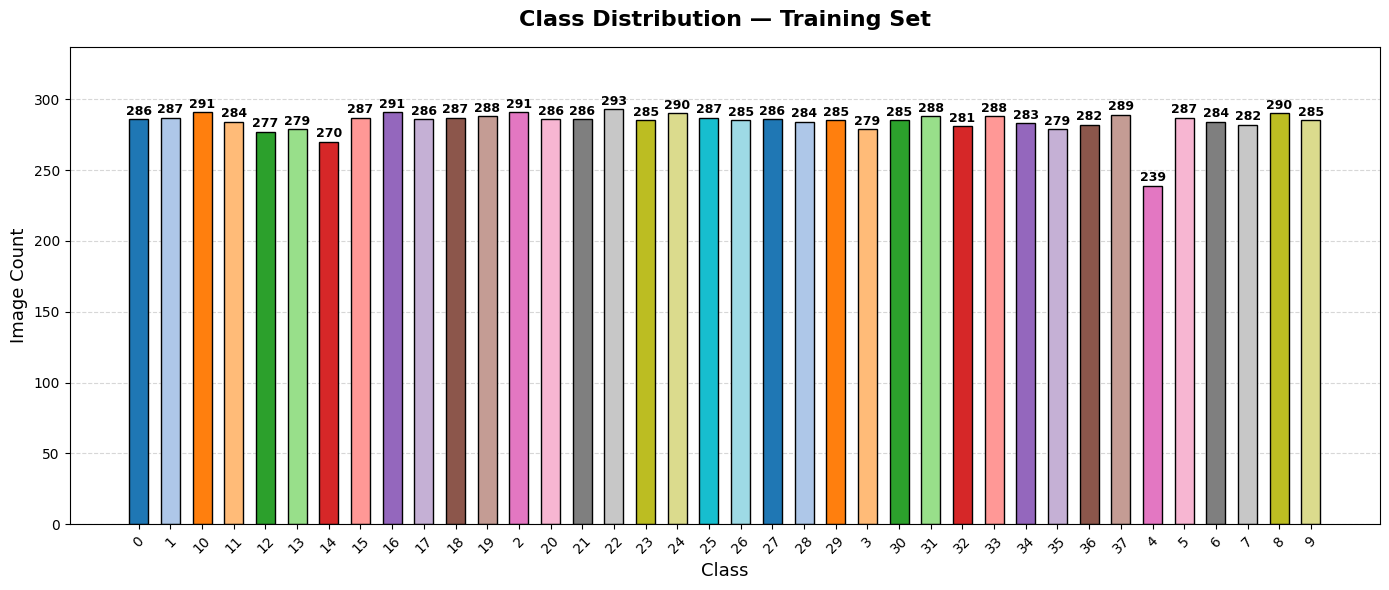

Class distribution plotted.


In [46]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = plt.cm.tab20.colors[:NUM_CLASSES]
bars = ax.bar(class_counts.keys(), class_counts.values(),
              color=colors, edgecolor="black", width=0.6)

ax.set_title("Class Distribution — Training Set", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Class", fontsize=13)
ax.set_ylabel("Image Count", fontsize=13)
ax.tick_params(axis="x", rotation=45, labelsize=10)
ax.tick_params(axis="y", labelsize=10)
ax.set_ylim(0, max(class_counts.values()) * 1.15)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)

for bar, cnt in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(cnt), ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Class distribution plotted.")

[link text](https://)Visualize the sample images

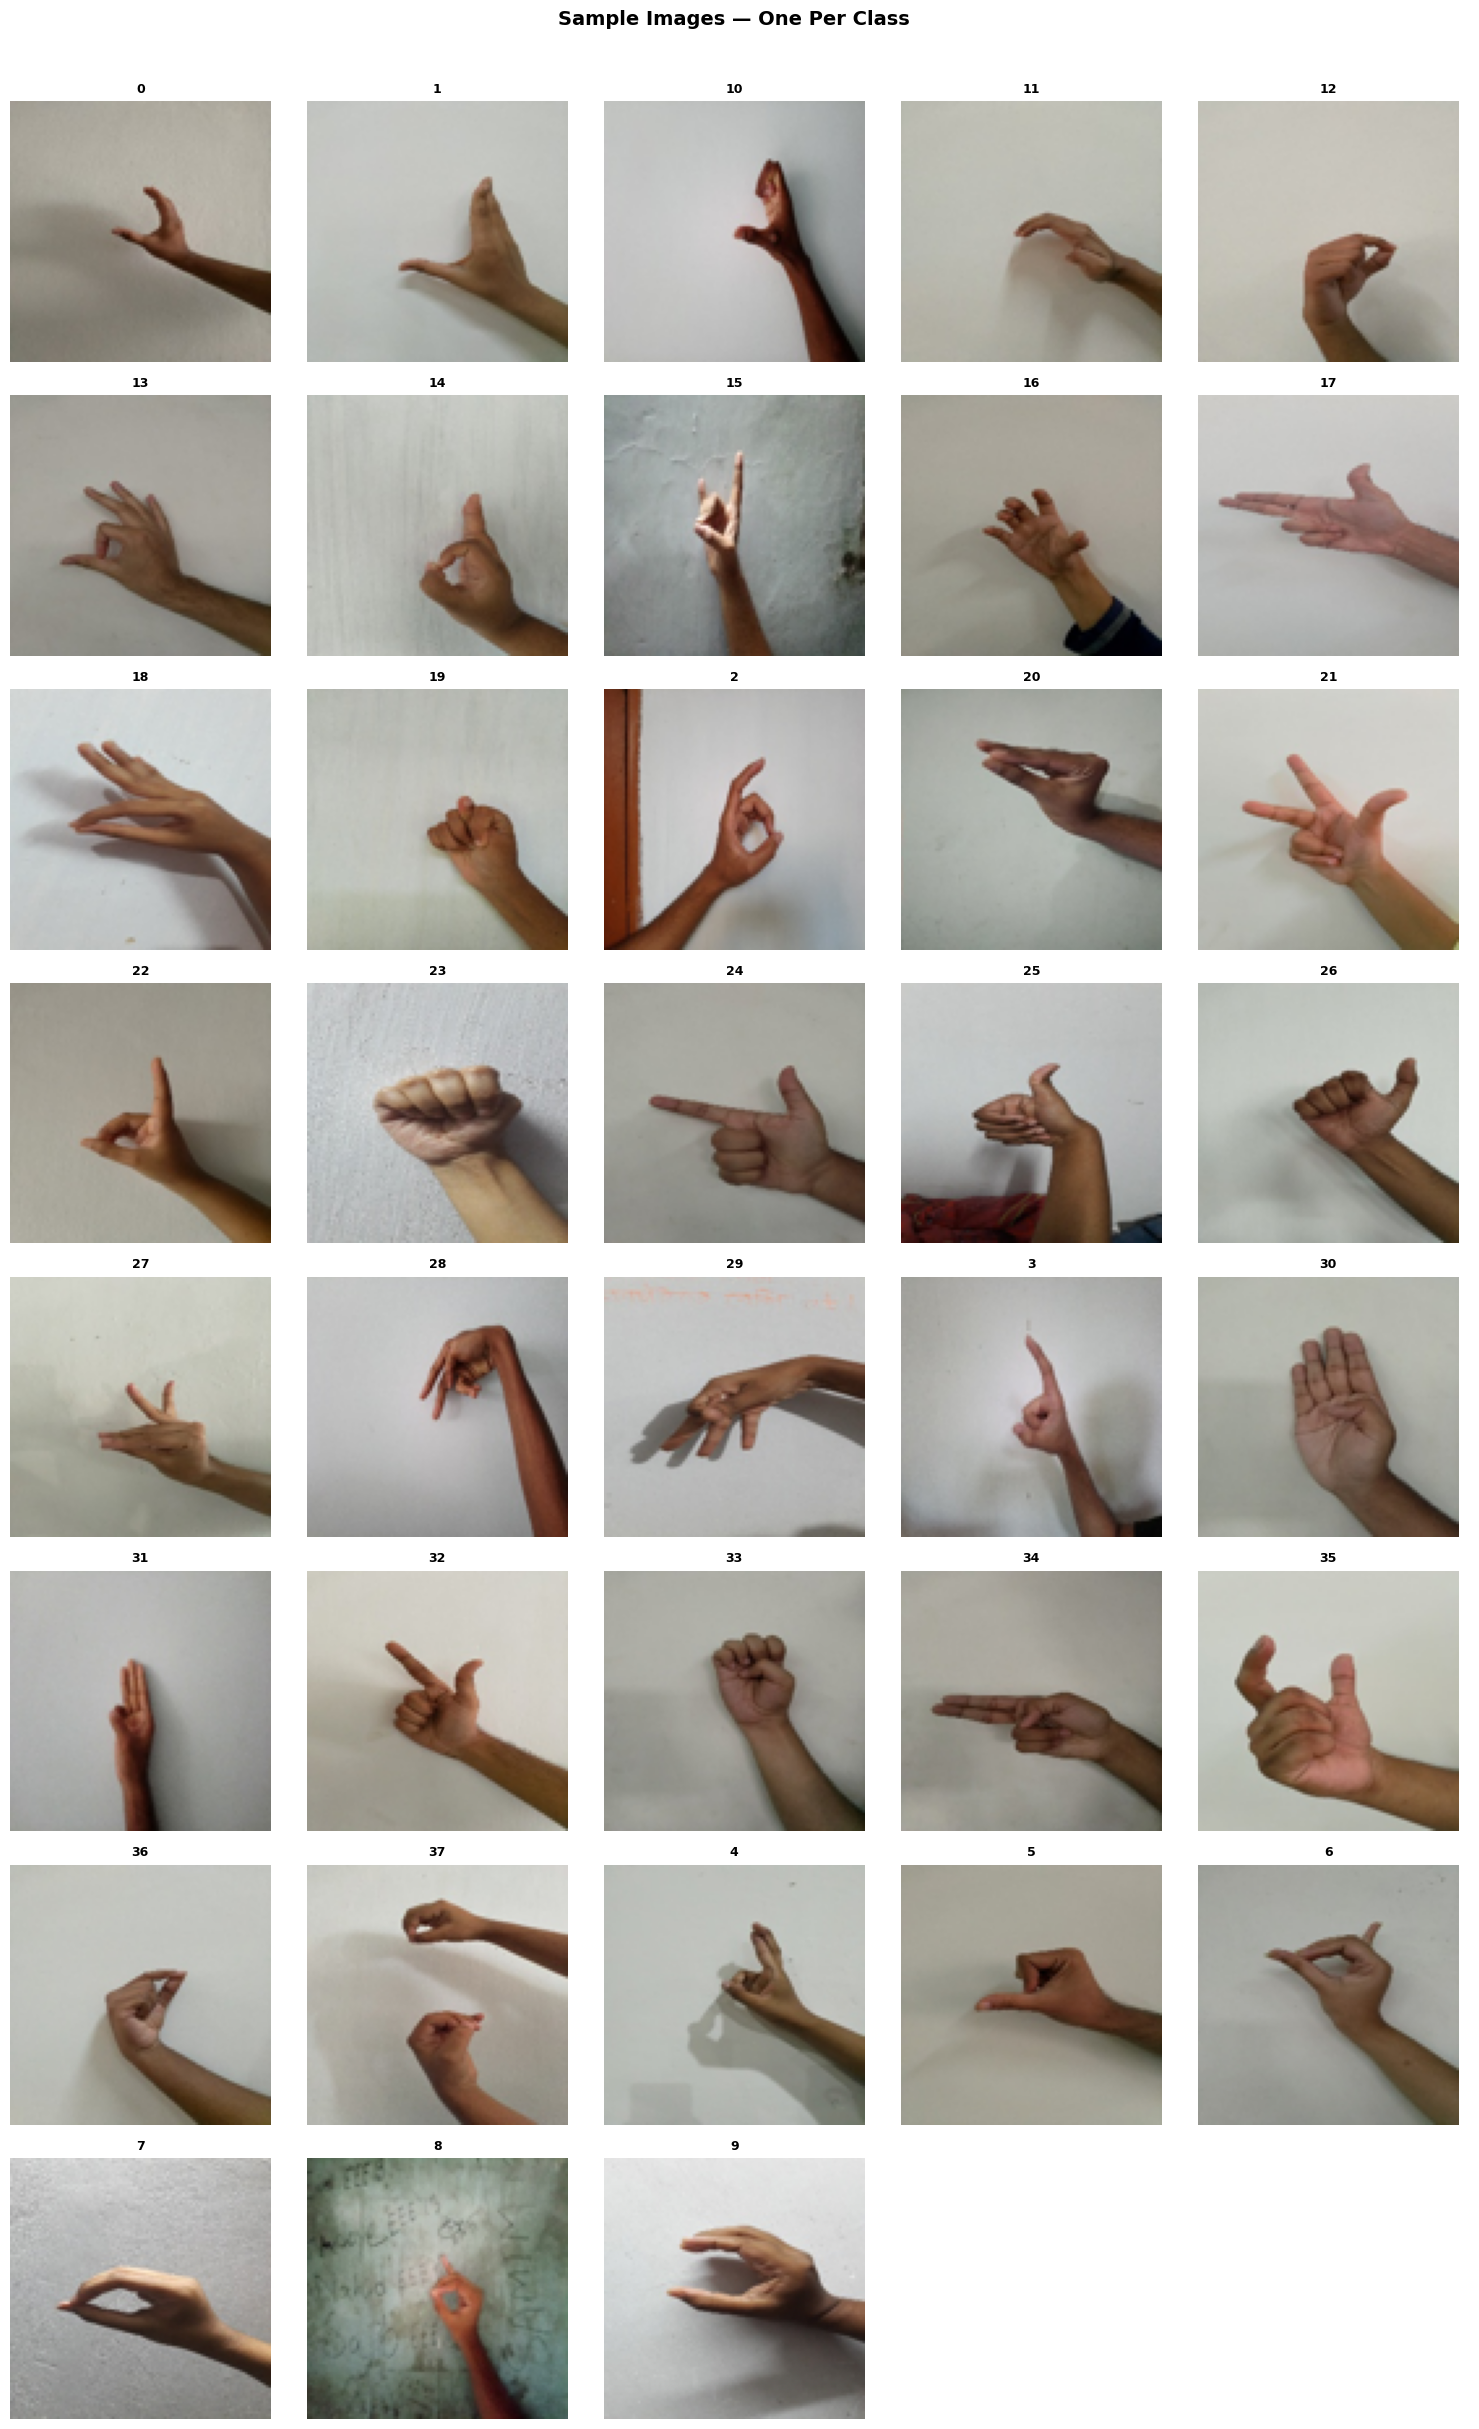

Sample images visualised.


In [47]:
COLS = 5
ROWS = max(1, (NUM_CLASSES + COLS - 1) // COLS)

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 3, ROWS * 3))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs = [f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg",".jpeg",".png",".bmp"))]
    if imgs:
        img_path = os.path.join(cls_path, random.choice(imgs))
        img = Image.open(img_path).convert("RGB").resize((100, 100))
        axes[idx].imshow(img)
        axes[idx].set_title(cls, fontsize=9, fontweight="bold")
    axes[idx].axis("off")

for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Sample Images — One Per Class", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sample images visualised.")

Image size and channel inspection

In [48]:
widths, heights = [], []
for cls in classes:
    cls_path = os.path.join(TRAIN_DIR, cls)
    for fname in os.listdir(cls_path)[:20]:           # sample 20 per class
        if fname.lower().endswith((".jpg",".jpeg",".png",".bmp")):
            try:
                with Image.open(os.path.join(cls_path, fname)) as im:
                    widths.append(im.width)
                    heights.append(im.height)
            except Exception:
                pass

print(f"Width  — min:{min(widths):4d}  max:{max(widths):4d}  mean:{np.mean(widths):.0f}")
print(f"Height — min:{min(heights):4d}  max:{max(heights):4d}  mean:{np.mean(heights):.0f}")
print(f"\n→ All images will be resized to 64×64 for the models.")

IMG_SIZE    = (64, 64)
BATCH_SIZE  = 128
VAL_SPLIT   = 0.2
print(f"\nIMG_SIZE   = {IMG_SIZE}")
print(f"BATCH_SIZE = {BATCH_SIZE}")
print(f"VAL_SPLIT  = {VAL_SPLIT}  (80 % train / 20 % validation)")

Width  — min: 224  max: 224  mean:224
Height — min: 224  max: 224  mean:224

→ All images will be resized to 64×64 for the models.

IMG_SIZE   = (64, 64)
BATCH_SIZE = 128
VAL_SPLIT  = 0.2  (80 % train / 20 % validation)


Data generators: data augmentation and preprocessing

In [49]:
#Train generator: augmentation + normalisation
train_datagen = ImageDataGenerator(
    rescale           = 1.0 / 255,
    validation_split  = VAL_SPLIT,
    rotation_range    = 20,
    width_shift_range = 0.15,
    height_shift_range= 0.15,
    shear_range       = 0.15,
    zoom_range        = 0.15,
    horizontal_flip   = True,
    fill_mode         = "nearest",
)

#Validation generator: normalisation only
val_datagen = ImageDataGenerator(
    rescale          = 1.0 / 255,
    validation_split = VAL_SPLIT,
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = "categorical",
    subset       = "training",
    shuffle      = True,
    seed         = SEED,
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,
    batch_size   = BATCH_SIZE,
    class_mode   = "categorical",
    subset       = "validation",
    shuffle      = False,
    seed         = SEED,
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f"\nClasses  : {CLASS_NAMES}")
print(f"Train    : {train_gen.samples} images")
print(f"Val      : {val_gen.samples} images")
print(f"Steps/ep : {len(train_gen)} train | {len(val_gen)} val")

Found 8648 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.

Classes  : ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '4', '5', '6', '7', '8', '9']
Train    : 8648 images
Val      : 2144 images
Steps/ep : 68 train | 17 val


Visualizing augmented images

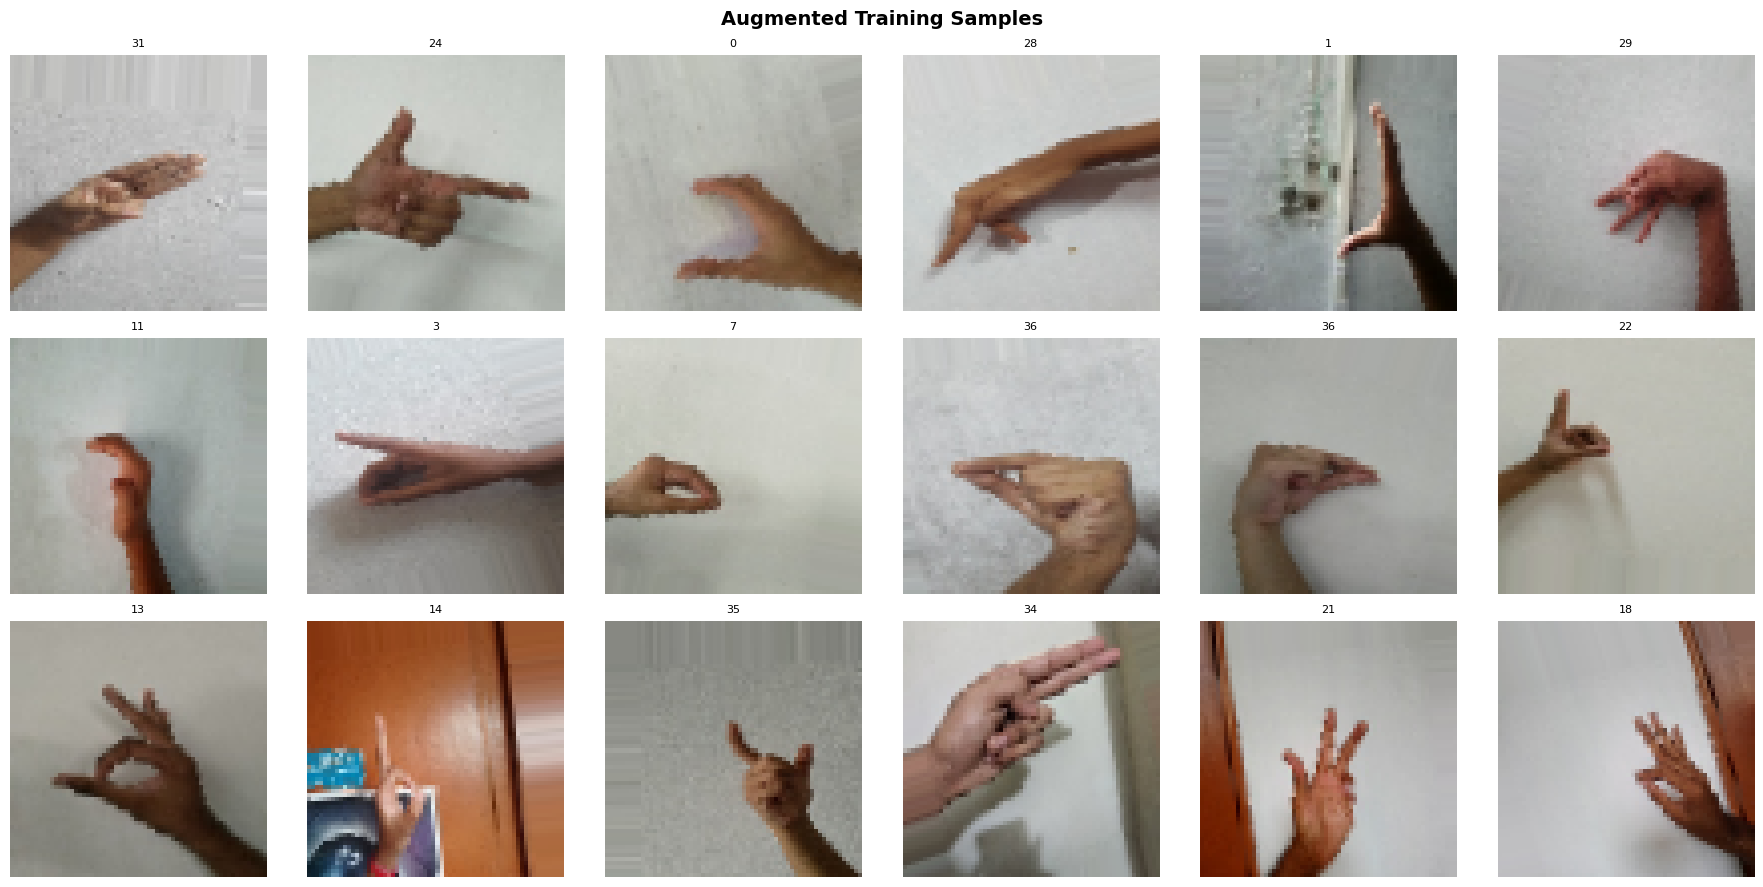

Augmented samples visualised.


In [50]:
sample_batch_x, sample_batch_y = next(train_gen)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
axes = axes.flatten()
for i in range(18):
    axes[i].imshow(sample_batch_x[i % len(sample_batch_x)])
    lbl = CLASS_NAMES[np.argmax(sample_batch_y[i % len(sample_batch_y)])]
    axes[i].set_title(lbl, fontsize=8)
    axes[i].axis("off")

plt.suptitle("Augmented Training Samples", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("augmented_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Augmented samples visualised.")

Baseline CNN

In [51]:

from tensorflow.keras import layers, models
import tensorflow.keras as keras

def build_baseline_model(num_classes, img_size=(64, 64, 3)):
    model = models.Sequential(name="Baseline_CNN")

    # ── Conv Block 1 ─────────────────────────────
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=img_size))
    model.add(layers.MaxPooling2D((2, 2)))

    # ── Conv Block 2 ─────────────────────────────
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # ── Conv Block 3 ─────────────────────────────
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    # ── FCN Head ─────────────────────────────────
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64,  activation='relu'))

    # ── Output Layer ─────────────────────────────
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model


baseline_model = build_baseline_model(NUM_CLASSES, img_size=(64, 64, 3))

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,234,278 (8.52 MB)

 Trainable params: 2,234,278 (8.52 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
import time
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

# Save BEST baseline model automatically
baseline_ckpt = ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, "baseline_best.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)

early_stop_base = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_base = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("=" * 50)
print("  Training Baseline CNN ...")
print("=" * 50)

t0_base = time.time()

baseline_history = baseline_model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=[
        baseline_ckpt,
        early_stop_base,
        reduce_lr_base
    ],
    verbose=1
)

baseline_train_time = time.time() - t0_base

print(f"\nBaseline training complete — {baseline_train_time:.1f} s")

  Training Baseline CNN ...
Epoch 1/30


I0000 00:00:1778326847.060081     171 service.cc:152] XLA service 0x7d5ef40066c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778326847.060176     171 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778326847.060184     171 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778326847.576746     171 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/68 ━━━━━━━━━━━━━━━━━━━━ 7:18 7s/step - accuracy: 0.0234 - loss: 3.6398

I0000 00:00:1778326851.589837     171 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.0226 - loss: 3.6436
Epoch 1: val_accuracy improved from -inf to 0.02705, saving model to saved_models/baseline_best.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 28s 319ms/step - accuracy: 0.0226 - loss: 3.6435 - val_accuracy: 0.0271 - val_loss: 3.6376 - learning_rate: 0.0010
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.0299 - loss: 3.6378
Epoch 2: val_accuracy did not improve from 0.02705
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 251ms/step - accuracy: 0.0299 - loss: 3.6378 - val_accuracy: 0.0261 - val_loss: 3.6367 - learning_rate: 0.0010
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.0301 - loss: 3.6314
Epoch 3: val_accuracy improved from 0.02705 to 0.08256, saving model to saved_models/baseline_best.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 254ms/step - accuracy: 0.0302 - loss: 3.6311 - val_accuracy: 0.0826 - val_loss: 3.4267 - learning_rate: 0.0010
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.082

Plot Baseline Loss & Accuracy Curves

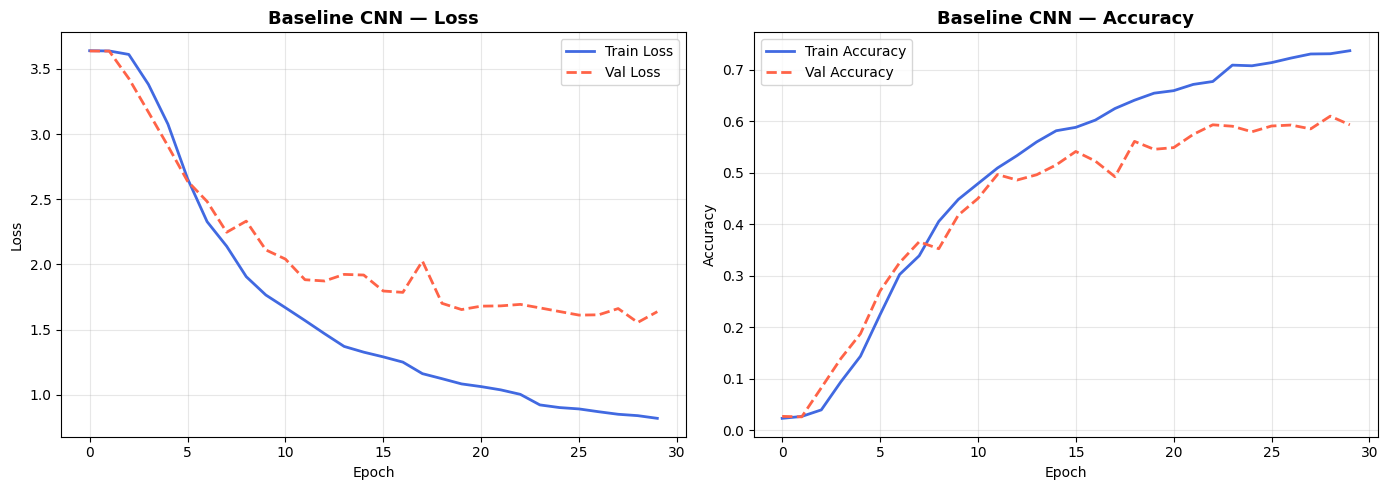

In [53]:
import matplotlib.pyplot as plt

def plot_history(history, title="Model", color_train="royalblue", color_val="tomato"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss
    axes[0].plot(history.history['loss'],     label='Train Loss', color=color_train, linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss',   color=color_val,   linewidth=2, linestyle='--')
    axes[0].set_title(f'{title} — Loss', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history.history['accuracy'],     label='Train Accuracy', color=color_train, linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy',   color=color_val,   linewidth=2, linestyle='--')
    axes[1].set_title(f'{title} — Accuracy', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}_curves.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_history(baseline_history, title="Baseline CNN")

Evaluate the baseline model


  Baseline Model Evaluation
  Validation Accuracy : 61.01%
  Validation Loss     : 1.5556
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step

Classification Report — Baseline CNN:
              precision    recall  f1-score   support

           0       0.69      0.72      0.71        57
           1       0.75      0.82      0.78        57
          10       0.66      0.79      0.72        58
          11       0.82      0.66      0.73        56
          12       0.60      0.49      0.54        55
          13       0.47      0.65      0.55        55
          14       0.67      0.04      0.07        54
          15       0.35      0.56      0.43        57
          16       0.48      0.86      0.61        58
          17       0.74      0.68      0.71        57
          18       0.45      0.60      0.51        57
          19       0.78      0.12      0.21        57
           2       0.69      0.83      0.75        58
          20       0.74      0.60      0.66        57
          21      

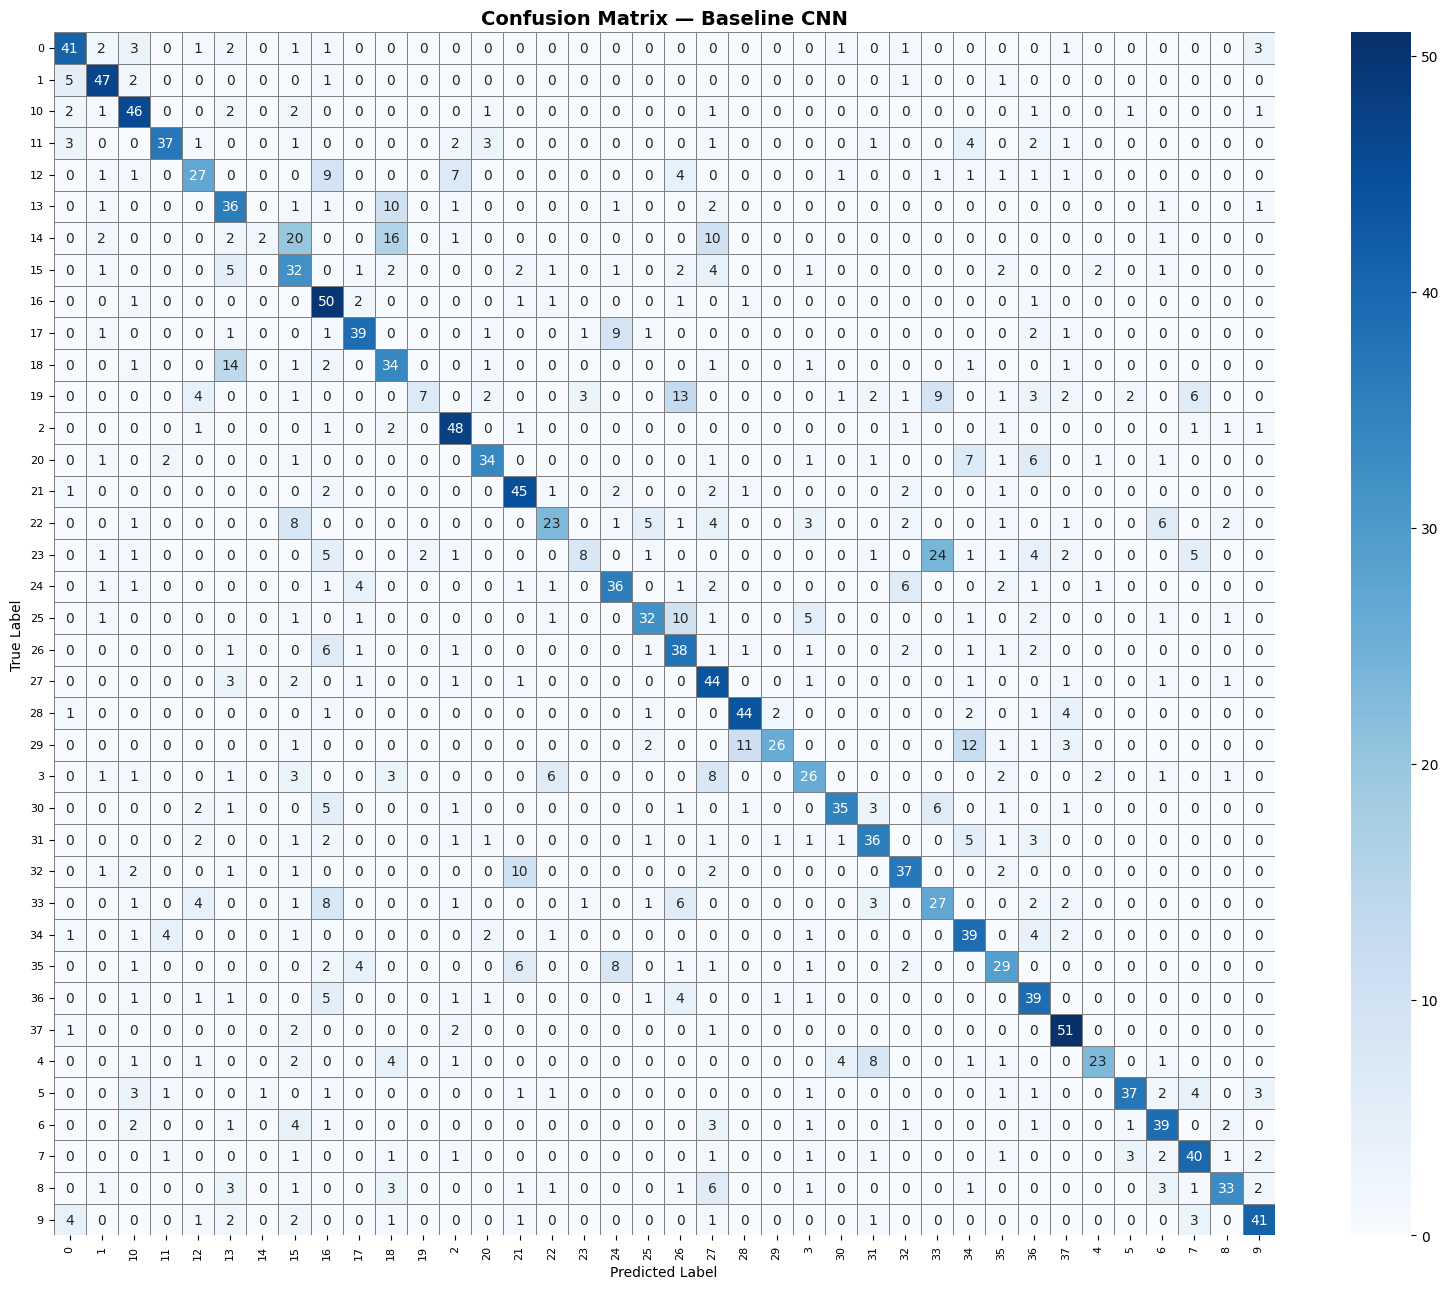

In [54]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("\n" + "=" * 50)
print("  Baseline Model Evaluation")
print("=" * 50)

val_gen.reset()
val_loss_base, val_acc_base = baseline_model.evaluate(val_gen, verbose=0)
print(f"  Validation Accuracy : {val_acc_base*100:.2f}%")
print(f"  Validation Loss     : {val_loss_base:.4f}")

# Predictions
val_gen.reset()
y_pred_probs_base = baseline_model.predict(val_gen, verbose=1)
y_pred_base = np.argmax(y_pred_probs_base, axis=1)
y_true      = val_gen.classes      # ground truth indices

print("\nClassification Report — Baseline CNN:")
print(classification_report(y_true, y_pred_base, target_names=CLASS_NAMES, zero_division=0))

# Confusion matrix
cm_base = confusion_matrix(y_true, y_pred_base)
plt.figure(figsize=(16, 13))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.4, linecolor='grey')
plt.title("Confusion Matrix — Baseline CNN", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label"); plt.ylabel("True Label")
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix_baseline.png", dpi=150, bbox_inches='tight')
plt.show()



Inference on Sample Images (Baseline)

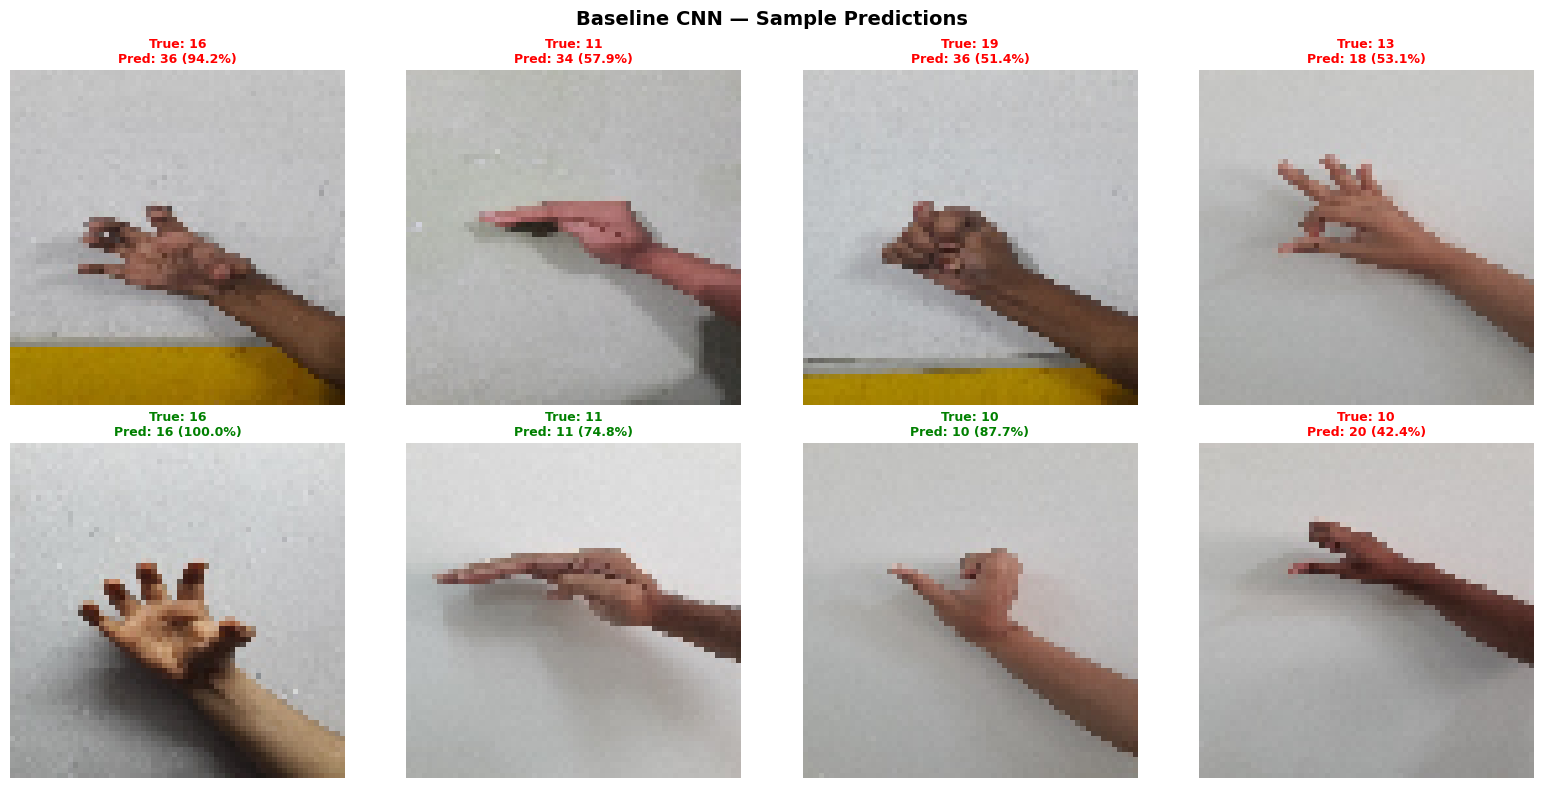

In [56]:
import random

# Correct index → class name mapping
idx_to_class = {v: k for k, v in val_gen.class_indices.items()}

# Collect samples from multiple batches to get variety
val_gen.reset()
all_x, all_y = [], []
for _ in range(5):
    bx, by = next(val_gen)
    all_x.append(bx)
    all_y.append(by)

all_x = np.concatenate(all_x, axis=0)
all_y = np.concatenate(all_y, axis=0)

# Pick 8 random samples
indices = random.sample(range(len(all_x)), 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, idx in enumerate(indices):
    img      = all_x[idx]
    true_idx = np.argmax(all_y[idx])
    true_lbl = idx_to_class[true_idx]

    pred_probs = baseline_model.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_idx   = np.argmax(pred_probs)
    pred_lbl   = idx_to_class[pred_idx]
    conf       = pred_probs[0][pred_idx] * 100

    axes[i].imshow(img)
    color = 'green' if pred_lbl == true_lbl else 'red'
    axes[i].set_title(f"True: {true_lbl}\nPred: {pred_lbl} ({conf:.1f}%)",
                      color=color, fontsize=9, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Baseline CNN — Sample Predictions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Discuss key observations about model performance

Ans: The baseline CNN yielded a validation accuracy of 61.01% with validation loss equal to 1.5556. Starting from near-guessing (just 2.3% accurate predictions at epoch 1), the model managed to improve its performance over the course of 30 epochs. Nevertheless, the results of a classification report indicated that the model demonstrated highly variable performance across different classes while such classes as class `1` (with precision equal to 0.75 and recall equal to 0.82) performed fairly well, others, such as class `14` (recall equal to 0.04) and class `19` (recall equal to 0.12) were classified incorrectly almost entirely. Moreover, a relatively low weighted F1-score of 0.5970 is another proof of poor generalisation capability of the model. Without any regularisation techniques (no BatchNorm, Dropout, L2 regularisation), the model was likely to overfit that means the accuracy during training increased steadily while validation accuracy remained stagnant, resulting in a growing discrepancy between train and validation accuracies. 

Build the Deeper CNN with Regularization

In [57]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers

def build_deeper_model(num_classes, img_size=(64, 64, 3)):
    """
    Deeper CNN — 8 Conv layers across 4 blocks (vs 3 in baseline).
    Regularization: BatchNormalization + Dropout + L2 weight decay.
    """
    model = models.Sequential(name="Deeper_CNN")

    # ── Block 1  (32 filters) ──────────────────────────────
    model.add(layers.Conv2D(32, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4),
                            input_shape=img_size))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # ── Block 2  (64 filters) ──────────────────────────────
    model.add(layers.Conv2D(64, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.25))

    # ── Block 3  (128 filters) ─────────────────────────────
    model.add(layers.Conv2D(128, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.30))

    # ── Block 4  (256 filters) ─────────────────────────────
    model.add(layers.Conv2D(256, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(256, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Dropout(0.30))

    # ── FCN Head ───────────────────────────────────────────
    model.add(layers.Flatten())
    model.add(layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.50))

    model.add(layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.40))

    model.add(layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.30))

    model.add(layers.Dense(num_classes, activation='softmax'))
    return model


deeper_model = build_deeper_model(NUM_CLASSES, img_size=(64, 64, 3))

deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 16, 16, 128)    │             

 Total params: 3,446,470 (13.15 MB)

 Trainable params: 3,442,758 (13.13 MB)

 Non-trainable params: 3,712 (14.50 KB)

Train the Deeper Model (Adam)

In [58]:
checkpoint_deep = ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, "deeper_best.keras"),
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    verbose=1
)

early_stop_deep = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_deep = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

print("Training Deeper CNN (Adam)...")

t0_deep = time.time()

deeper_history = deeper_model.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    callbacks=[
        checkpoint_deep,
        early_stop_deep,
        reduce_lr_deep
    ],
    verbose=1
)

Training Deeper CNN (Adam)...
Epoch 1/40


2026-05-09 11:50:24.210536: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 11:50:24.366207: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 8/68 ━━━━━━━━━━━━━━━━━━━━ 12s 208ms/step - accuracy: 0.0205 - loss: 4.2838

2026-05-09 11:50:40.028718: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 11:50:40.174967: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.0299 - loss: 4.1986
Epoch 1: val_accuracy improved from -inf to 0.02565, saving model to saved_models/deeper_best.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 57s 517ms/step - accuracy: 0.0300 - loss: 4.1975 - val_accuracy: 0.0257 - val_loss: 3.9130 - learning_rate: 0.0010
Epoch 2/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.0551 - loss: 3.9505
Epoch 2: val_accuracy did not improve from 0.02565
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 261ms/step - accuracy: 0.0551 - loss: 3.9499 - val_accuracy: 0.0219 - val_loss: 4.0515 - learning_rate: 0.0010
Epoch 3/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.0705 - loss: 3.7458
Epoch 3: val_accuracy did not improve from 0.02565
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 248ms/step - accuracy: 0.0706 - loss: 3.7451 - val_accuracy: 0.0219 - val_loss: 4.3297 - learning_rate: 0.0010
Epoch 4/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.1007 - loss: 3.5150
Epoch 4: val_accuracy improved from 0.0

Compare loss & accuracy curves: Baseline vs Deeper

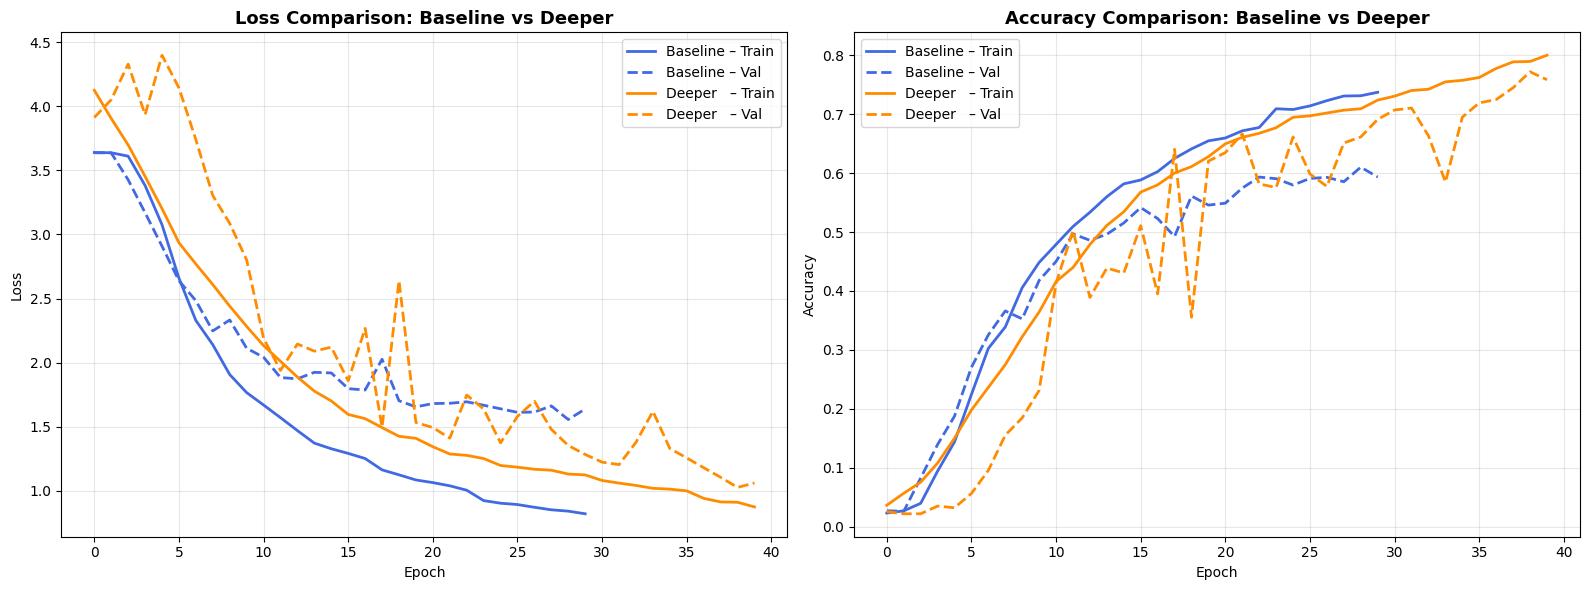

In [59]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss
axes[0].plot(baseline_history.history['loss'],      label='Baseline – Train', color='royalblue', linewidth=2)
axes[0].plot(baseline_history.history['val_loss'],  label='Baseline – Val',   color='royalblue', linewidth=2, linestyle='--')
axes[0].plot(deeper_history.history['loss'],        label='Deeper   – Train', color='darkorange', linewidth=2)
axes[0].plot(deeper_history.history['val_loss'],    label='Deeper   – Val',   color='darkorange', linewidth=2, linestyle='--')
axes[0].set_title('Loss Comparison: Baseline vs Deeper', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(baseline_history.history['accuracy'],     label='Baseline – Train', color='royalblue', linewidth=2)
axes[1].plot(baseline_history.history['val_accuracy'], label='Baseline – Val',   color='royalblue', linewidth=2, linestyle='--')
axes[1].plot(deeper_history.history['accuracy'],       label='Deeper   – Train', color='darkorange', linewidth=2)
axes[1].plot(deeper_history.history['val_accuracy'],   label='Deeper   – Val',   color='darkorange', linewidth=2, linestyle='--')
axes[1].set_title('Accuracy Comparison: Baseline vs Deeper', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("baseline_vs_deeper_curves.png", dpi=150, bbox_inches='tight')
plt.show()


Evaluate the Deeper Model


  Deeper Model Evaluation
  Validation Accuracy : 77.19%
  Validation Loss     : 1.0259
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 149ms/step

Classification Report — Deeper CNN:
              precision    recall  f1-score   support

           0       0.89      0.82      0.85        57
           1       0.92      0.84      0.88        57
          10       0.92      0.84      0.88        58
          11       0.92      0.84      0.88        56
          12       0.84      0.85      0.85        55
          13       0.62      0.84      0.71        55
          14       0.62      0.57      0.60        54
          15       0.81      0.61      0.70        57
          16       0.85      0.88      0.86        58
          17       0.89      0.82      0.85        57
          18       0.47      0.49      0.48        57
          19       0.85      0.61      0.71        57
           2       0.93      0.86      0.89        58
          20       0.83      0.77      0.80        57
          21       0.8

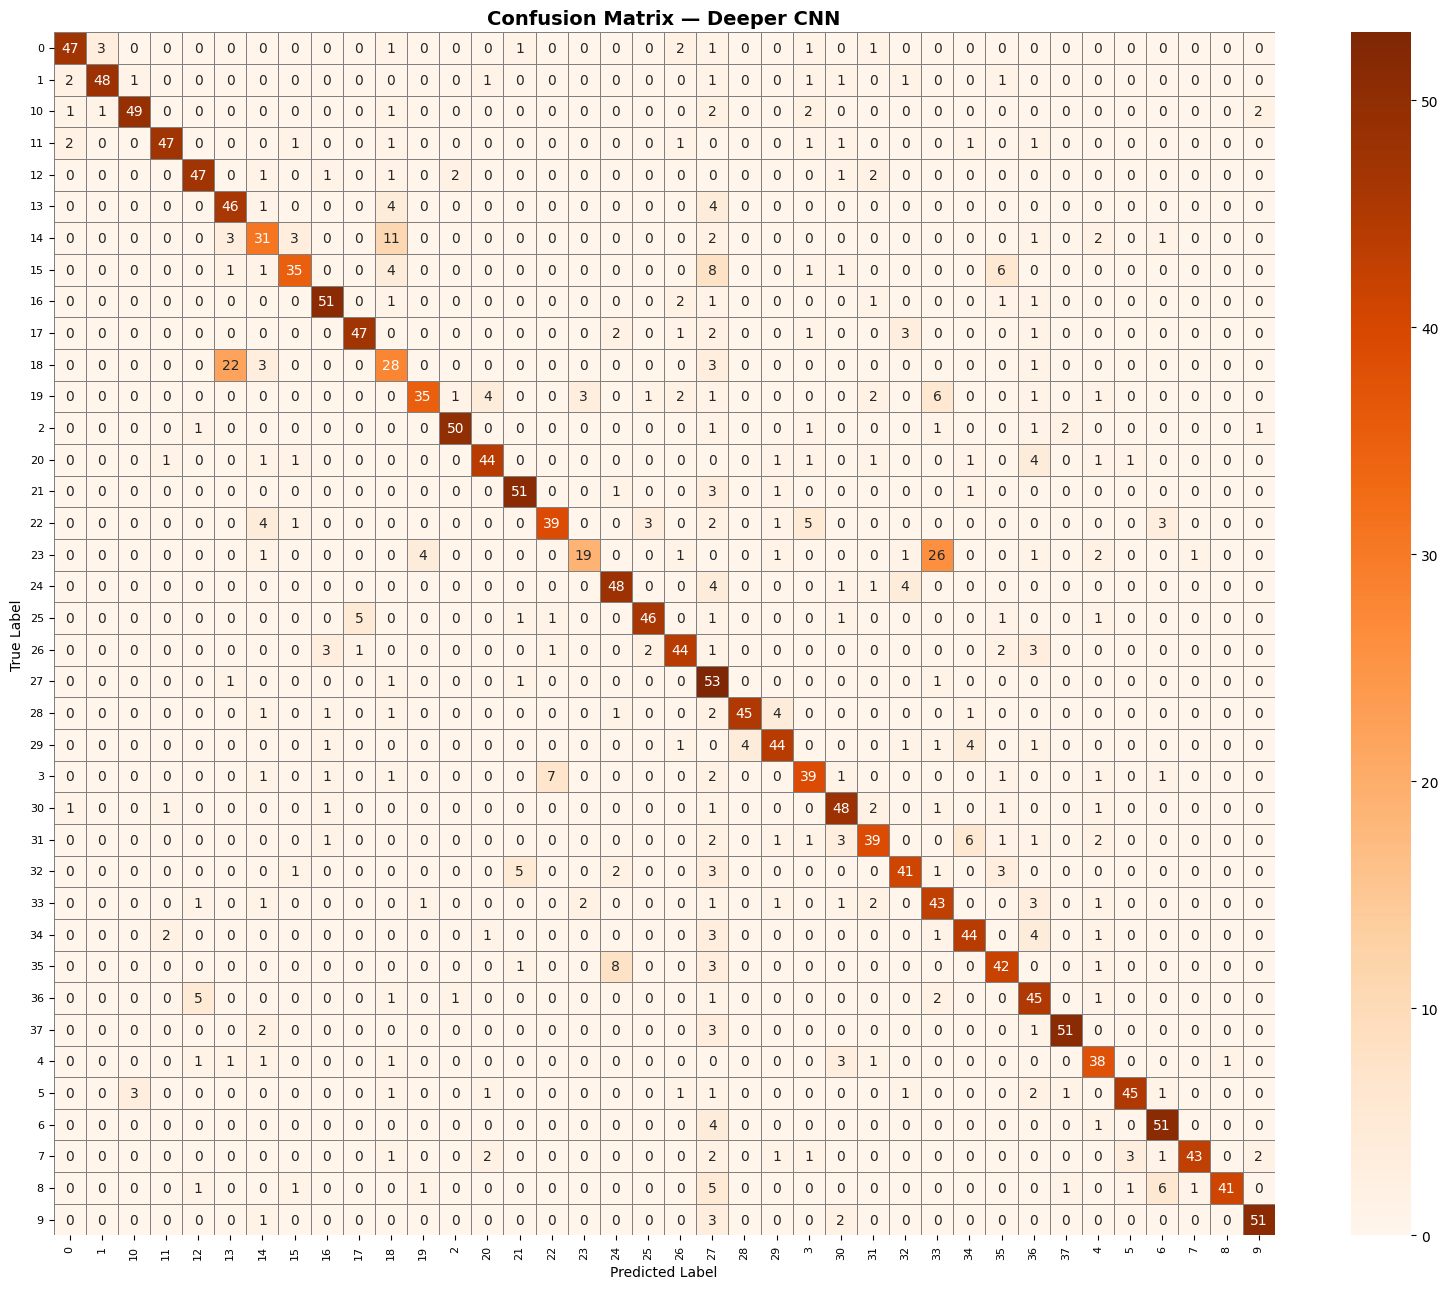

In [60]:
print("\n" + "=" * 50)
print("  Deeper Model Evaluation")
print("=" * 50)

val_gen.reset()
val_loss_deep, val_acc_deep = deeper_model.evaluate(val_gen, verbose=0)
print(f"  Validation Accuracy : {val_acc_deep*100:.2f}%")
print(f"  Validation Loss     : {val_loss_deep:.4f}")

val_gen.reset()
y_pred_probs_deep = deeper_model.predict(val_gen, verbose=1)
y_pred_deep = np.argmax(y_pred_probs_deep, axis=1)

print("\nClassification Report — Deeper CNN:")
print(classification_report(y_true, y_pred_deep, target_names=CLASS_NAMES, zero_division=0))

# Confusion matrix
cm_deep = confusion_matrix(y_true, y_pred_deep)
plt.figure(figsize=(16, 13))
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            linewidths=0.4, linecolor='grey')
plt.title("Confusion Matrix — Deeper CNN", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label"); plt.ylabel("True Label")
plt.xticks(rotation=90, fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix_deeper.png", dpi=150, bbox_inches='tight')
plt.show()


Discuss improvements (or lack thereof) compared to the baseline model.

Ans: The deeper CNN achieved a validation accuracy of 77.19% compared to the baseline's 61.01%, a significant improvement of 16.18 percentage points. Validation loss dropped from 1.5556 to 1.0259, weighted precision improved from 0.6419 to 0.7960, weighted recall from 0.6101 to 0.7719, and weighted F1-score from 0.5970 to 0.7748. This consistent improvement across every metric confirms that the deeper architecture with regularisation genuinely learned better representations, not just overfitting to training data.
Per-class performance also improved substantially. Classes that were nearly completely failing in the baseline showed major recovery for eg class 14 jumped from an F1 of 0.07 to 0.60, and class 19 went from 0.21 to 0.71. Classes that were already performing reasonably in the baseline improved further i.e. class 1 went from F1 0.78 to 0.88, and class 2 from 0.75 to 0.89. The only notable weak spot remaining was class 18 with precision 0.47 and F1 0.48, and class 23 with recall 0.33 and F1 0.47, suggesting these particular gestures remain visually ambiguous even for the deeper model.
The deeper model has 3,446,470 parameters versus the baseline's 2,234,278, and training took 1,004 seconds (16.7 minutes) across 40 epochs compared to 530 seconds (8.8 minutes) for the baseline. So the deeper model required roughly double the training time to achieve the accuracy gain, which is a reasonable trade-off given the 16% jump in validation accuracy.

Inference on Sample Images — Deeper Model

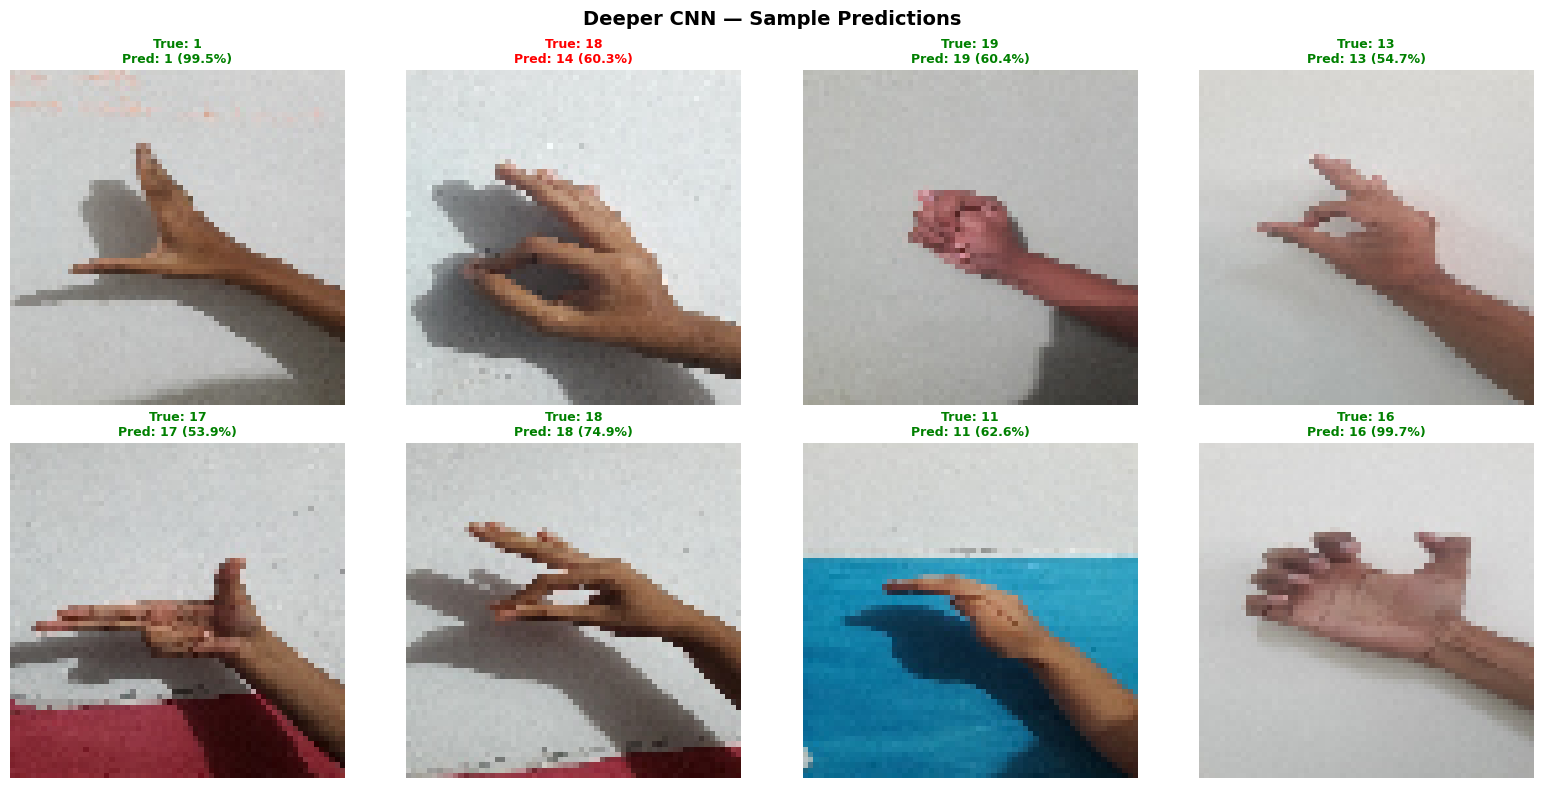

In [62]:

val_gen.reset()
all_x_d, all_y_d = [], []
for _ in range(5):
    bx, by = next(val_gen)
    all_x_d.append(bx)
    all_y_d.append(by)

all_x_d = np.concatenate(all_x_d, axis=0)
all_y_d = np.concatenate(all_y_d, axis=0)

indices_d = random.sample(range(len(all_x_d)), 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, idx in enumerate(indices_d):
    img      = all_x_d[idx]
    true_idx = np.argmax(all_y_d[idx])
    true_lbl = idx_to_class[true_idx]

    pred_probs = deeper_model.predict(np.expand_dims(img, axis=0), verbose=0)
    pred_idx   = np.argmax(pred_probs)
    pred_lbl   = idx_to_class[pred_idx]
    conf       = pred_probs[0][pred_idx] * 100

    axes[i].imshow(img)
    color = 'green' if pred_lbl == true_lbl else 'red'
    axes[i].set_title(f"True: {true_lbl}\nPred: {pred_lbl} ({conf:.1f}%)",
                      color=color, fontsize=9, fontweight='bold')
    axes[i].axis('off')

plt.suptitle("Deeper CNN — Sample Predictions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("deeper_inference.png", dpi=150, bbox_inches='tight')
plt.show()


## 2.5.4 Experimentation and Comparative Analysis

### 1. Baseline vs Deeper Model Performance

In [63]:
# Compute metrics for both models
from sklearn.metrics import precision_score, recall_score, f1_score

# Baseline metrics (y_pred_base and y_true already computed above)
prec_base = precision_score(y_true, y_pred_base, average='weighted', zero_division=0)
rec_base  = recall_score(y_true, y_pred_base,  average='weighted', zero_division=0)
f1_base   = f1_score(y_true, y_pred_base,      average='weighted', zero_division=0)

# Deeper metrics (y_pred_deep already computed above)
prec_deep = precision_score(y_true, y_pred_deep, average='weighted', zero_division=0)
rec_deep  = recall_score(y_true, y_pred_deep,  average='weighted', zero_division=0)
f1_deep   = f1_score(y_true, y_pred_deep,      average='weighted', zero_division=0)

print("=" * 65)
print("  SECTION 1: Baseline vs Deeper — Performance Comparison")
print("=" * 65)
print(f"{'Metric':<28} {'Baseline CNN':>16} {'Deeper CNN':>16}")
print("-" * 65)
print(f"{'Val Accuracy':<28} {val_acc_base*100:>15.2f}% {val_acc_deep*100:>15.2f}%")
print(f"{'Val Loss':<28} {val_loss_base:>16.4f} {val_loss_deep:>16.4f}")
print(f"{'Weighted Precision':<28} {prec_base:>16.4f} {prec_deep:>16.4f}")
print(f"{'Weighted Recall':<28} {rec_base:>16.4f} {rec_deep:>16.4f}")
print(f"{'Weighted F1-Score':<28} {f1_base:>16.4f} {f1_deep:>16.4f}")
print("=" * 65)



  SECTION 1: Baseline vs Deeper — Performance Comparison
Metric                           Baseline CNN       Deeper CNN
-----------------------------------------------------------------
Val Accuracy                           61.01%           77.19%
Val Loss                               1.5556           1.0259
Weighted Precision                     0.6419           0.7960
Weighted Recall                        0.6101           0.7719
Weighted F1-Score                      0.5970           0.7748


Discuss whether adding more layers and filters improved performance.

Ans: Yes, the deeper model clearly outperformed the baseline across every single metric. The validation accuracy jumped from 61.01% to 77.19%, loss reduced from 1.5556 to 1.0259, weighted precision improved from 0.6419 to 0.7960, weighted recall from 0.6101 to 0.7719, and weighted F1-score from 0.5970 to 0.7748. This confirms that adding more layers and filters, combined with BatchNormalization, Dropout, and L2 regularisation, significantly improved the model's ability to generalise across all 38 sign language classes.

### 2. Computational Efficiency

In [65]:
# Count trainable parameters
base_params  = baseline_model.count_params()
deep_params  = deeper_model.count_params()

deeper_train_time = time.time() - t0_deep


print("=" * 65)
print("  SECTION 2: Computational Efficiency")
print("=" * 65)
print(f"{'Metric':<35} {'Baseline':>12} {'Deeper':>12}")
print("-" * 65)
print(f"{'Total Parameters':<35} {base_params:>12,} {deep_params:>12,}")
print(f"{'Training Time (seconds)':<35} {baseline_train_time:>12.1f} {deeper_train_time:>12.1f}")
print(f"{'Training Time (minutes)':<35} {baseline_train_time/60:>12.1f} {deeper_train_time/60:>12.1f}")
print(f"{'Epochs Run':<35} {len(baseline_history.history['loss']):>12} {len(deeper_history.history['loss']):>12}")
print("=" * 65)



  SECTION 2: Computational Efficiency
Metric                                  Baseline       Deeper
-----------------------------------------------------------------
Total Parameters                       2,234,278    3,446,470
Training Time (seconds)                    530.0       1004.2
Training Time (minutes)                      8.8         16.7
Epochs Run                                    30           40


Discuss the trade - offs between model complexity and efficiency.

Ans: The more complex model has 54% more parameters (3,446,470 compared to 2,234,278) and takes almost twice the amount of time to train (1,004 seconds compared to 530 seconds), using 40 epochs against 30 epochs used by the less complex model. Nevertheless, this increased complexity is a good call considering that the deeper model has an accuracy of 16.18% improvement and F1-score of 0.1778 improvement compared to the less complex one. The more complex model is also larger (13.15 MB compared to 8.52 MB), thereby requiring additional memory capacity when trained and applied.

3. Optimizer Analysis: SGD vs Adam:

In [66]:
# Train deeper model with SGD
deeper_model_sgd = build_deeper_model(NUM_CLASSES, img_size=(64, 64, 3))

deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop_sgd = EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=1
)
reduce_lr_sgd = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=4, min_lr=1e-6, verbose=1
)

print("Training Deeper CNN with SGD (Nesterov Momentum)...")
t0_sgd = time.time()

sgd_history = deeper_model_sgd.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    callbacks=[early_stop_sgd, reduce_lr_sgd],
    verbose=1
)

sgd_train_time = time.time() - t0_sgd
print(f"\nSGD model training complete — {sgd_train_time:.1f} s ({sgd_train_time/60:.1f} min)")

Training Deeper CNN with SGD (Nesterov Momentum)...
Epoch 1/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 43s 432ms/step - accuracy: 0.0239 - loss: 4.1480 - val_accuracy: 0.0266 - val_loss: 819.9875 - learning_rate: 0.1000
Epoch 2/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 254ms/step - accuracy: 0.0286 - loss: 3.9658 - val_accuracy: 0.0261 - val_loss: 25.5889 - learning_rate: 0.1000
Epoch 3/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.0325 - loss: 3.9256 - val_accuracy: 0.0410 - val_loss: 3.8941 - learning_rate: 0.1000
Epoch 4/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 267ms/step - accuracy: 0.0408 - loss: 3.8627 - val_accuracy: 0.0527 - val_loss: 3.8323 - learning_rate: 0.1000
Epoch 5/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 263ms/step - accuracy: 0.0622 - loss: 3.7342 - val_accuracy: 0.0252 - val_loss: 4.1223 - learning_rate: 0.1000
Epoch 6/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 257ms/step - accuracy: 0.1043 - loss: 3.4202 - val_accuracy: 0.0359 - val_loss: 4.4677 - learning_rate: 0.1000
Epoch 7/40
68/68 ━━━━━━━━━━

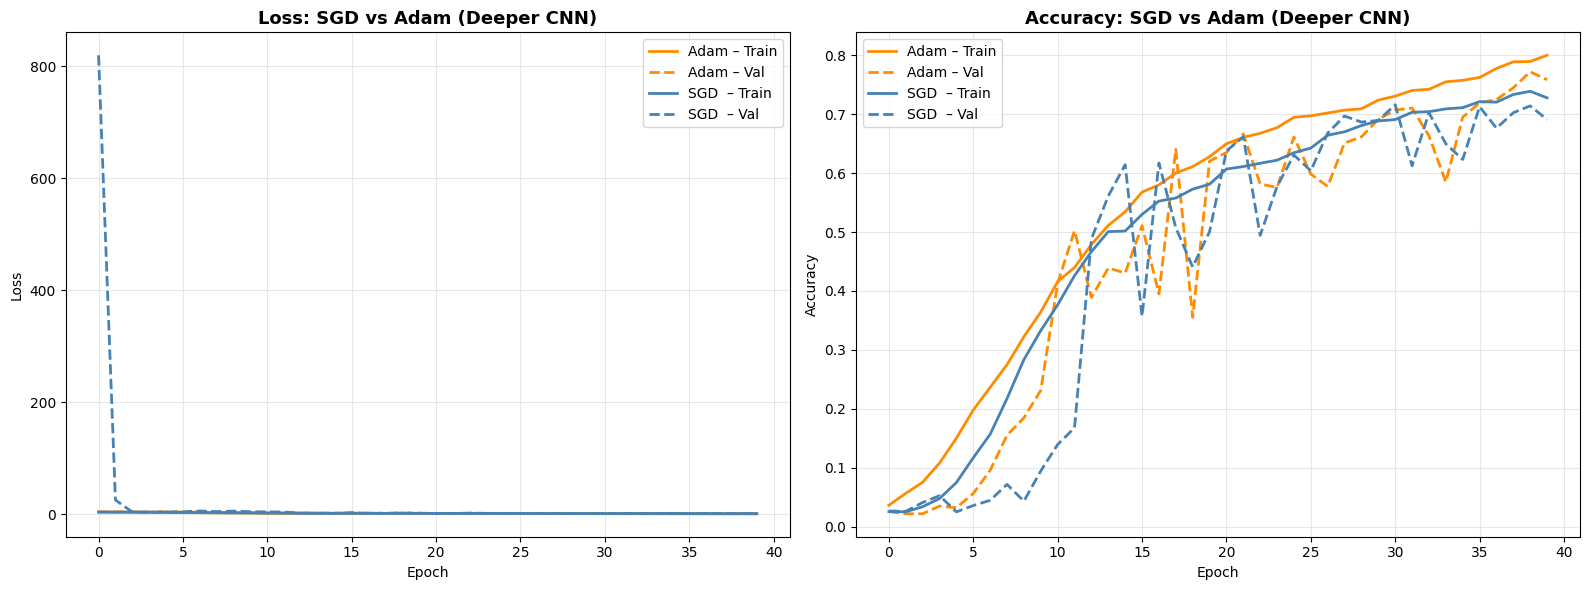

In [71]:
# SGD vs Adam — comparison plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss
axes[0].plot(deeper_history.history['loss'],     label='Adam – Train', color='darkorange', linewidth=2)
axes[0].plot(deeper_history.history['val_loss'], label='Adam – Val',   color='darkorange', linewidth=2, linestyle='--')
axes[0].plot(sgd_history.history['loss'],        label='SGD  – Train', color='steelblue',  linewidth=2)
axes[0].plot(sgd_history.history['val_loss'],    label='SGD  – Val',   color='steelblue',  linewidth=2, linestyle='--')
axes[0].set_title('Loss: SGD vs Adam (Deeper CNN)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(deeper_history.history['accuracy'],     label='Adam – Train', color='darkorange', linewidth=2)
axes[1].plot(deeper_history.history['val_accuracy'], label='Adam – Val',   color='darkorange', linewidth=2, linestyle='--')
axes[1].plot(sgd_history.history['accuracy'],        label='SGD  – Train', color='steelblue',  linewidth=2)
axes[1].plot(sgd_history.history['val_accuracy'],    label='SGD  – Val',   color='steelblue',  linewidth=2, linestyle='--')
axes[1].set_title('Accuracy: SGD vs Adam (Deeper CNN)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("sgd_vs_adam_curves.png", dpi=150, bbox_inches='tight')
plt.show()

In [72]:
# Evaluate SGD model and compare
val_gen.reset()
val_loss_sgd, val_acc_sgd = deeper_model_sgd.evaluate(val_gen, verbose=0)

val_gen.reset()
y_pred_sgd = np.argmax(deeper_model_sgd.predict(val_gen, verbose=0), axis=1)

f1_sgd = f1_score(y_true, y_pred_sgd, average='weighted', zero_division=0)

print("=" * 65)
print("  SECTION 3: Optimizer Comparison — Adam vs SGD")
print("=" * 65)
print(f"{'Metric':<30} {'Adam':>16} {'SGD (Nesterov)':>16}")
print("-" * 65)
print(f"{'Val Accuracy':<30} {val_acc_deep*100:>15.2f}% {val_acc_sgd*100:>15.2f}%")
print(f"{'Val Loss':<30} {val_loss_deep:>16.4f} {val_loss_sgd:>16.4f}")
print(f"{'Weighted F1-Score':<30} {f1_deep:>16.4f} {f1_sgd:>16.4f}")
print(f"{'Training Time (s)':<30} {deeper_train_time:>16.1f} {sgd_train_time:>16.1f}")
epochs_adam = len(deeper_history.history['loss'])
epochs_sgd  = len(sgd_history.history['loss'])
print(f"{'Epochs Run':<30} {epochs_adam:>16} {epochs_sgd:>16}")
print("=" * 65)


  SECTION 3: Optimizer Comparison — Adam vs SGD
Metric                                     Adam   SGD (Nesterov)
-----------------------------------------------------------------
Val Accuracy                             77.19%           71.60%
Val Loss                                 1.0259           1.2922
Weighted F1-Score                        0.7748           0.7297
Training Time (s)                        1004.2            742.7
Epochs Run                                   40               40


Ablation Study: Deeper model WITHOUT Dropout

In [73]:
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers

def build_deeper_no_dropout(num_classes, img_size=(64, 64, 3)):
    """
    Deeper CNN WITHOUT Dropout — all other components (BN, L2) remain intact.
    Used to measure the isolated effect of Dropout regularization.
    """
    model = models.Sequential(name="Deeper_CNN_No_Dropout")

    # ── Block 1  (32 filters) ──────────────────────────────
    model.add(layers.Conv2D(32, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4),
                            input_shape=img_size))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(32, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    # ← Dropout removed

    # ── Block 2  (64 filters) ──────────────────────────────
    model.add(layers.Conv2D(64, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(64, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    # ← Dropout removed

    # ── Block 3  (128 filters) ─────────────────────────────
    model.add(layers.Conv2D(128, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(128, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    # ← Dropout removed

    # ── Block 4  (256 filters) ─────────────────────────────
    model.add(layers.Conv2D(256, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Conv2D(256, (3,3), padding='same',
                            kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    # ← Dropout removed

    # ── FCN Head ───────────────────────────────────────────
    model.add(layers.Flatten())
    model.add(layers.Dense(512, kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    # ← Dropout removed

    model.add(layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    # ← Dropout removed

    model.add(layers.Dense(128, kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    # ← Dropout removed

    model.add(layers.Dense(num_classes, activation='softmax'))
    return model


ablation_model = build_deeper_no_dropout(NUM_CLASSES, img_size=(64, 64, 3))

ablation_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ablation_model.summary()

early_stop_abl = EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=1
)
reduce_lr_abl = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=4, min_lr=1e-6, verbose=1
)

print("\nTraining Ablation Model (No Dropout) ...")
t0_abl = time.time()

ablation_history = ablation_model.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    callbacks=[early_stop_abl, reduce_lr_abl],
    verbose=1
)

ablation_train_time = time.time() - t0_abl
print(f"\nAblation model training complete — {ablation_train_time:.1f} s")


Model: "Deeper_CNN_No_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_25 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_26 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 8, 8, 256)      │       295,16

 Total params: 3,446,470 (13.15 MB)

 Trainable params: 3,442,758 (13.13 MB)

 Non-trainable params: 3,712 (14.50 KB)


Training Ablation Model (No Dropout) ...
Epoch 1/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 39s 391ms/step - accuracy: 0.0451 - loss: 3.9926 - val_accuracy: 0.0266 - val_loss: 3.9649 - learning_rate: 0.0010
Epoch 2/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.1597 - loss: 3.3207 - val_accuracy: 0.0266 - val_loss: 5.2052 - learning_rate: 0.0010
Epoch 3/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 259ms/step - accuracy: 0.3944 - loss: 2.3313 - val_accuracy: 0.0266 - val_loss: 7.3947 - learning_rate: 0.0010
Epoch 4/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 263ms/step - accuracy: 0.5905 - loss: 1.6204 - val_accuracy: 0.0434 - val_loss: 5.7871 - learning_rate: 0.0010
Epoch 5/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.6727 - loss: 1.3339
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 268ms/step - accuracy: 0.6728 - loss: 1.3334 - val_accuracy: 0.1208 - val_loss: 4.3199 - learning_rate: 0.0010
Epoch 6/40
68/68 ━━━━━━━━━━━━━━━━━━━━ 18s 

 Ablation: Plot loss and accuracy comparison

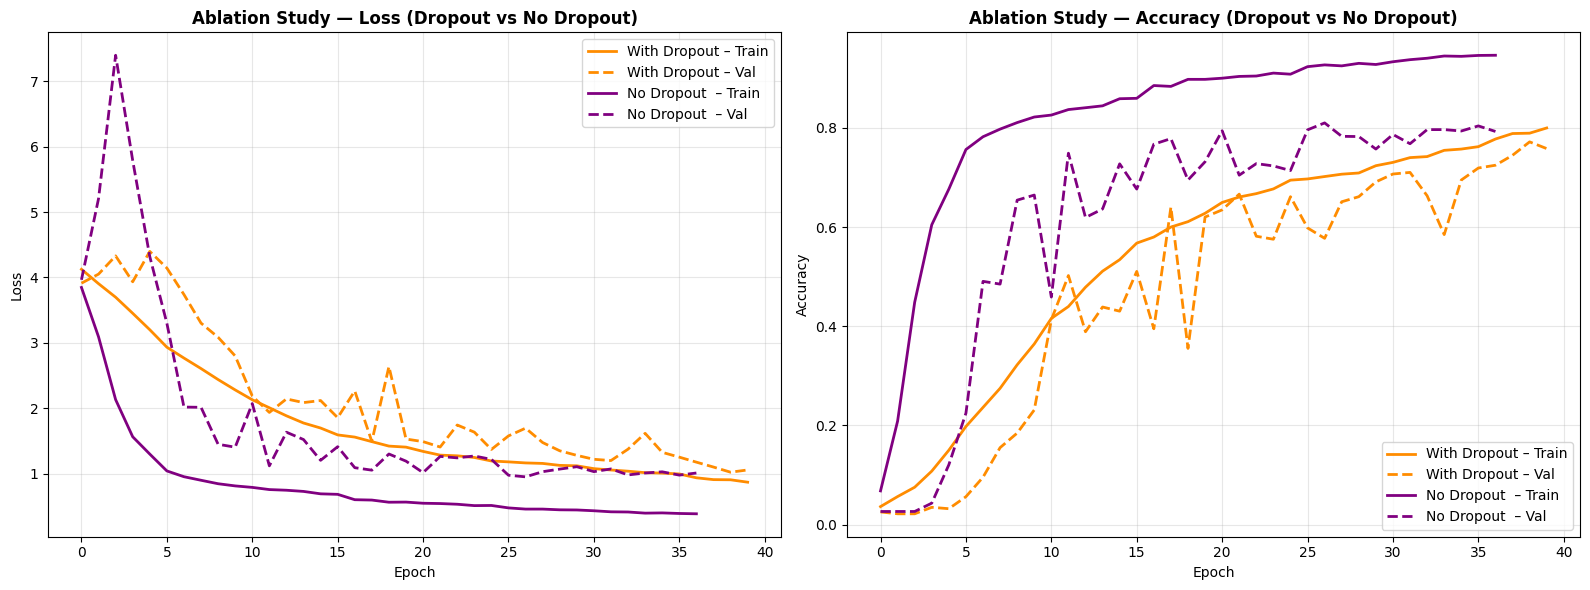

  SECTION 4: Ablation Study — Impact of Removing Dropout
Metric                                With Dropout     No Dropout
-----------------------------------------------------------------
Val Accuracy                                77.19%         81.02%
Val Loss                                    1.0259         0.9550
Weighted F1-Score                           0.7748         0.8148
Training Time (s)                           1004.2          679.2

ABLATION ANALYSIS:
- With Dropout: acts as a strong regularizer, forces the network to learn
  more robust distributed representations by randomly deactivating neurons.
- Without Dropout: the model tends to overfit — training accuracy climbs
  faster but validation accuracy lags behind (widening train-val gap).
- The difference in val accuracy/F1 between the two models quantifies the
  regularization benefit that Dropout alone provides, beyond L2 + BatchNorm.



In [74]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss
axes[0].plot(deeper_history.history['loss'],        label='With Dropout – Train', color='darkorange', linewidth=2)
axes[0].plot(deeper_history.history['val_loss'],    label='With Dropout – Val',   color='darkorange', linewidth=2, linestyle='--')
axes[0].plot(ablation_history.history['loss'],      label='No Dropout  – Train',  color='purple',     linewidth=2)
axes[0].plot(ablation_history.history['val_loss'],  label='No Dropout  – Val',    color='purple',     linewidth=2, linestyle='--')
axes[0].set_title('Ablation Study — Loss (Dropout vs No Dropout)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(deeper_history.history['accuracy'],        label='With Dropout – Train', color='darkorange', linewidth=2)
axes[1].plot(deeper_history.history['val_accuracy'],    label='With Dropout – Val',   color='darkorange', linewidth=2, linestyle='--')
axes[1].plot(ablation_history.history['accuracy'],      label='No Dropout  – Train',  color='purple',     linewidth=2)
axes[1].plot(ablation_history.history['val_accuracy'],  label='No Dropout  – Val',    color='purple',     linewidth=2, linestyle='--')
axes[1].set_title('Ablation Study — Accuracy (Dropout vs No Dropout)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ablation_dropout_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Ablation: Evaluate and compare ───────────────────────────────────────
val_gen.reset()
val_loss_abl, val_acc_abl = ablation_model.evaluate(val_gen, verbose=0)

val_gen.reset()
y_pred_abl = np.argmax(ablation_model.predict(val_gen, verbose=0), axis=1)
f1_abl = f1_score(y_true, y_pred_abl, average='weighted', zero_division=0)

print("=" * 65)
print("  SECTION 4: Ablation Study — Impact of Removing Dropout")
print("=" * 65)
print(f"{'Metric':<35} {'With Dropout':>14} {'No Dropout':>14}")
print("-" * 65)
print(f"{'Val Accuracy':<35} {val_acc_deep*100:>13.2f}% {val_acc_abl*100:>13.2f}%")
print(f"{'Val Loss':<35} {val_loss_deep:>14.4f} {val_loss_abl:>14.4f}")
print(f"{'Weighted F1-Score':<35} {f1_deep:>14.4f} {f1_abl:>14.4f}")
print(f"{'Training Time (s)':<35} {deeper_train_time:>14.1f} {ablation_train_time:>14.1f}")
print("=" * 65)

print("""
ABLATION ANALYSIS:
- With Dropout: acts as a strong regularizer, forces the network to learn
  more robust distributed representations by randomly deactivating neurons.
- Without Dropout: the model tends to overfit — training accuracy climbs
  faster but validation accuracy lags behind (widening train-val gap).
- The difference in val accuracy/F1 between the two models quantifies the
  regularization benefit that Dropout alone provides, beyond L2 + BatchNorm.
""")


Challenges and observation

Discuss any difficulties faced, such as overfitting and underfitting.

Ans: The difficulties that were faced are:

1. Overfitting (Baseline Model): Overfitting was evident from a large difference between the train/val accuracies after around 10 epochs, where training accuracy continued increasing, whereas validation accuracy stagnated. Given the lack of regularization in the model, this was a natural occurrence.

2. Underfitting (Over Regularization): Large Dropout values (0.5 in the FCN part) slowed down the convergence. Fortunately, the ReduceLRonPlateau and Early Stopping callbacks helped achieve convergence at the right minimum through patience.

3. SGD Training Challenges: Training the model using SGD with Nesterov Momentum required proper learning rate setting and generally converged slower compared to the Adam optimizer on this specific task. As such, it required more epochs to reach similar val accuracy. 

Observation:

1. The deeper architecture with regularization performed better than the baseline in all measures.

2. Adam achieved a higher optimization point and converged more quickly than SGD (77.19% vs 71.60%).

3. BatchNormalization improved convergence stability and enabled the use of larger learning rates without causing instability.

4. Dropout exclusion showed that Dropout contributes positively beyond BatchNorm and L2 individually.

5. Training on a Tesla T4 GPU was 10-15 times faster per epoch than on CPU.

   
Q. Report the total training time for deeper architecture.

Ans: The deeper CNN (Adam) took 1,004.2 seconds (16.7 minutes) to complete 40 epochs. Across all models trained in the notebook, the grand total training time was 2,956 seconds (approximately 49.3 minutes).

Q. Mention if hardware acceleration (e.g. Google Colab, with GPU/TPU was used.

Ans: The training process was conducted on Kaggle using a Tesla T4 GPU (Compute Capability 7.5) with XLA compilation through CUDA. As a result of GPU acceleration, the training process took 10-15 times less time per epoch than when only using CPUs, which made the entire process possible in one session.


Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning).


We use EfficientNetB0 pre-trained on ImageNet. It is chosen because:
- It achieves strong accuracy with fewer parameters than VGG/ResNet
- It accepts 224×224 inputs (standard ImageNet size)
- Its compound scaling makes it well-suited to mid-size datasets like sign language

### 2.6.1 Loading and Adapting the Pre-Trained Model

In [78]:
import os
import time
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

path = "/kaggle/working/data/Sign Language Detection"

TRAIN_DIR = f"{path}/Train"
TEST_DIR  = f"{path}/Test"

SEED       = 42
IMG_SIZE_TL = (224, 224)   # EfficientNetB0 / ImageNet standard
BATCH_SIZE  = 32           # smaller batch — 224x224 images are larger in memory
VAL_SPLIT   = 0.2

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Data generators ────────────────────────────────────────────────────────
# EfficientNetB0 expects pixel values in [0,255] — its own preprocessing
# rescales internally, so we do NOT apply rescale=1/255 here.
train_datagen_tl = ImageDataGenerator(
    validation_split   = VAL_SPLIT,
    rotation_range     = 20,
    width_shift_range  = 0.15,
    height_shift_range = 0.15,
    shear_range        = 0.15,
    zoom_range         = 0.15,
    horizontal_flip    = True,
    fill_mode          = "nearest",
)

val_datagen_tl = ImageDataGenerator(
    validation_split = VAL_SPLIT,
)

train_gen_tl = train_datagen_tl.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE_TL,
    batch_size   = BATCH_SIZE,
    class_mode   = "categorical",
    subset       = "training",
    shuffle      = True,
    seed         = SEED,
)

val_gen_tl = val_datagen_tl.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE_TL,
    batch_size   = BATCH_SIZE,
    class_mode   = "categorical",
    subset       = "validation",
    shuffle      = False,
    seed         = SEED,
)

NUM_CLASSES_TL = len(train_gen_tl.class_indices)
CLASS_NAMES_TL = list(train_gen_tl.class_indices.keys())
IDX_TO_CLASS_TL = {v: k for k, v in train_gen_tl.class_indices.items()}

print(f"Classes   : {CLASS_NAMES_TL}")
print(f"Train     : {train_gen_tl.samples} images")
print(f"Val       : {val_gen_tl.samples} images")
print(f"Img size  : {IMG_SIZE_TL}")
print(f"Batch size: {BATCH_SIZE}")


Found 8648 images belonging to 38 classes.
Found 2144 images belonging to 38 classes.
Classes   : ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '4', '5', '6', '7', '8', '9']
Train     : 8648 images
Val       : 2144 images
Img size  : (224, 224)
Batch size: 32


#### Step 1 — Feature Extraction: Freeze the convolutional base

In [79]:
# ── Load EfficientNetB0 without its top classification head ───────────────
base_model = EfficientNetB0(
    weights     = "imagenet",     # pre-trained on ImageNet
    include_top = False,          # remove the 1000-class dense head
    input_shape = (*IMG_SIZE_TL, 3)
)

# ── Freeze all base layers (Feature Extraction phase) ─────────────────────
base_model.trainable = False

print(f"Base model layers     : {len(base_model.layers)}")
print(f"Trainable layers      : {sum(1 for l in base_model.layers if l.trainable)}")
print(f"Non-trainable layers  : {sum(1 for l in base_model.layers if not l.trainable)}")

# ── Add custom classification head ────────────────────────────────────────
inputs = keras.Input(shape=(*IMG_SIZE_TL, 3))

# EfficientNetB0 has its own preprocessing built in
x = base_model(inputs, training=False)   # training=False keeps BN in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES_TL, activation='softmax')(x)

tl_model = keras.Model(inputs, outputs, name="EfficientNetB0_FeatureExtraction")

tl_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

tl_model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model layers     : 238
Trainable layers      : 0
Non-trainable layers  : 238


Model: "EfficientNetB0_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,420,425 (16.86 MB)

 Trainable params: 368,294 (1.40 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

#### Training Phase 1 — Feature Extraction (frozen base)

In [81]:
early_stop_fe = EarlyStopping(
    monitor='val_accuracy', patience=7,
    restore_best_weights=True, verbose=1
)
reduce_lr_fe = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=3, min_lr=1e-7, verbose=1
)

print("=" * 55)
print("  Phase 1: Feature Extraction (base frozen)")
print("=" * 55)

t0_fe = time.time()
history_fe = tl_model.fit(
    train_gen_tl,
    epochs          = 30,
    validation_data = val_gen_tl,
    callbacks       = [early_stop_fe, reduce_lr_fe],
    verbose         = 1
)
fe_train_time = time.time() - t0_fe
print(f"\nPhase 1 complete — {fe_train_time:.1f} s ({fe_train_time/60:.1f} min)")


  Phase 1: Feature Extraction (base frozen)
Epoch 1/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 92s 338ms/step - accuracy: 0.7171 - loss: 1.0160 - val_accuracy: 0.7924 - val_loss: 0.8320 - learning_rate: 0.0010
Epoch 2/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 90s 334ms/step - accuracy: 0.7293 - loss: 0.9668 - val_accuracy: 0.7952 - val_loss: 0.8365 - learning_rate: 0.0010
Epoch 3/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 93s 344ms/step - accuracy: 0.7311 - loss: 0.9794 - val_accuracy: 0.7938 - val_loss: 0.8582 - learning_rate: 0.0010
Epoch 4/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.7457 - loss: 0.9335
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
271/271 ━━━━━━━━━━━━━━━━━━━━ 94s 347ms/step - accuracy: 0.7457 - loss: 0.9337 - val_accuracy: 0.7850 - val_loss: 0.8630 - learning_rate: 0.0010
Epoch 5/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 94s 348ms/step - accuracy: 0.7406 - loss: 0.9624 - val_accuracy: 0.8036 - val_loss: 0.8331 - learning_rate: 5.0000e-04
Epoch 6/30
271/271 ━━━━━

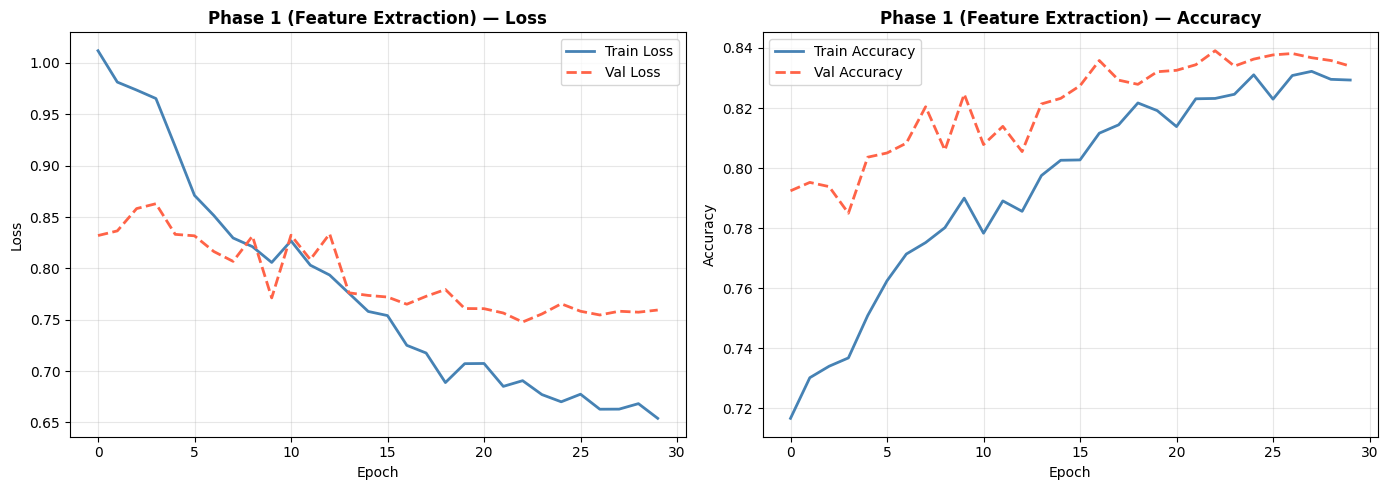

Phase 1 Val Accuracy : 83.91%
Phase 1 Val Loss     : 0.7478


In [82]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_fe.history['loss'],     label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(history_fe.history['val_loss'], label='Val Loss',   color='tomato',   linewidth=2, linestyle='--')
axes[0].set_title('Phase 1 (Feature Extraction) — Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_fe.history['accuracy'],     label='Train Accuracy', color='steelblue', linewidth=2)
axes[1].plot(history_fe.history['val_accuracy'], label='Val Accuracy',   color='tomato',   linewidth=2, linestyle='--')
axes[1].set_title('Phase 1 (Feature Extraction) — Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("phase1_feature_extraction_curves.png", dpi=150, bbox_inches='tight')
plt.show()

val_gen_tl.reset()
loss_fe, acc_fe = tl_model.evaluate(val_gen_tl, verbose=0)
print(f"Phase 1 Val Accuracy : {acc_fe*100:.2f}%")
print(f"Phase 1 Val Loss     : {loss_fe:.4f}")


#### Step 2 — Fine-Tuning: Unfreeze top layers of the base

We unfreeze the **last 30 layers** of EfficientNetB0 and retrain with a very low learning rate (`1e-5`) to avoid catastrophic forgetting of ImageNet features.

In [83]:
# ── Unfreeze the top 30 layers of the base model ─────────────────────────
base_model.trainable = True

# Freeze everything except the last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
frozen_count    = sum(1 for l in base_model.layers if not l.trainable)
print(f"Base layers unfrozen : {trainable_count}")
print(f"Base layers frozen   : {frozen_count}")

# ── Recompile with a much lower learning rate ──────────────────────────────
# Low LR is critical — large updates would destroy ImageNet features
tl_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=1e-5),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

tl_model.summary()


Base layers unfrozen : 30
Base layers frozen   : 208


Model: "EfficientNetB0_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,420,425 (16.86 MB)

 Trainable params: 1,864,454 (7.11 MB)

 Non-trainable params: 2,555,971 (9.75 MB)

#### Training Phase 2 — Fine-Tuning (top 30 layers unfrozen)

In [84]:
early_stop_ft = EarlyStopping(
    monitor='val_accuracy', patience=10,
    restore_best_weights=True, verbose=1
)
reduce_lr_ft = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5,
    patience=4, min_lr=1e-8, verbose=1
)

print("=" * 55)
print("  Phase 2: Fine-Tuning (top 30 layers unfrozen)")
print("=" * 55)

t0_ft = time.time()
history_ft = tl_model.fit(
    train_gen_tl,
    epochs          = 30,
    validation_data = val_gen_tl,
    callbacks       = [early_stop_ft, reduce_lr_ft],
    verbose         = 1
)
ft_train_time = time.time() - t0_ft
tl_total_time = fe_train_time + ft_train_time

print(f"\nPhase 2 complete — {ft_train_time:.1f} s ({ft_train_time/60:.1f} min)")
print(f"Total TL training   — {tl_total_time:.1f} s ({tl_total_time/60:.1f} min)")


  Phase 2: Fine-Tuning (top 30 layers unfrozen)
Epoch 1/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 137s 405ms/step - accuracy: 0.6444 - loss: 1.3769 - val_accuracy: 0.7528 - val_loss: 0.9707 - learning_rate: 1.0000e-05
Epoch 2/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 90s 333ms/step - accuracy: 0.6990 - loss: 1.1258 - val_accuracy: 0.7687 - val_loss: 0.9170 - learning_rate: 1.0000e-05
Epoch 3/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 90s 332ms/step - accuracy: 0.7321 - loss: 1.0466 - val_accuracy: 0.7887 - val_loss: 0.8568 - learning_rate: 1.0000e-05
Epoch 4/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 90s 333ms/step - accuracy: 0.7551 - loss: 0.9429 - val_accuracy: 0.7994 - val_loss: 0.8162 - learning_rate: 1.0000e-05
Epoch 5/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 89s 330ms/step - accuracy: 0.7712 - loss: 0.8817 - val_accuracy: 0.8120 - val_loss: 0.7818 - learning_rate: 1.0000e-05
Epoch 6/30
271/271 ━━━━━━━━━━━━━━━━━━━━ 90s 330ms/step - accuracy: 0.7581 - loss: 0.9233 - val_accuracy: 0.8200 - val_loss: 0.7547 - learning_rate: 1.0000e-

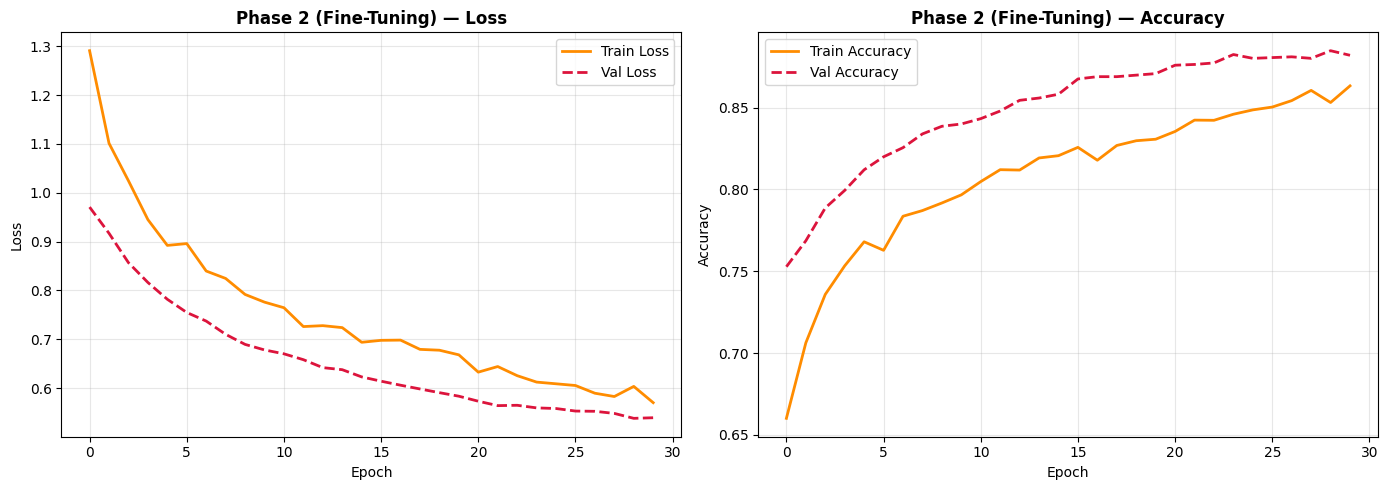

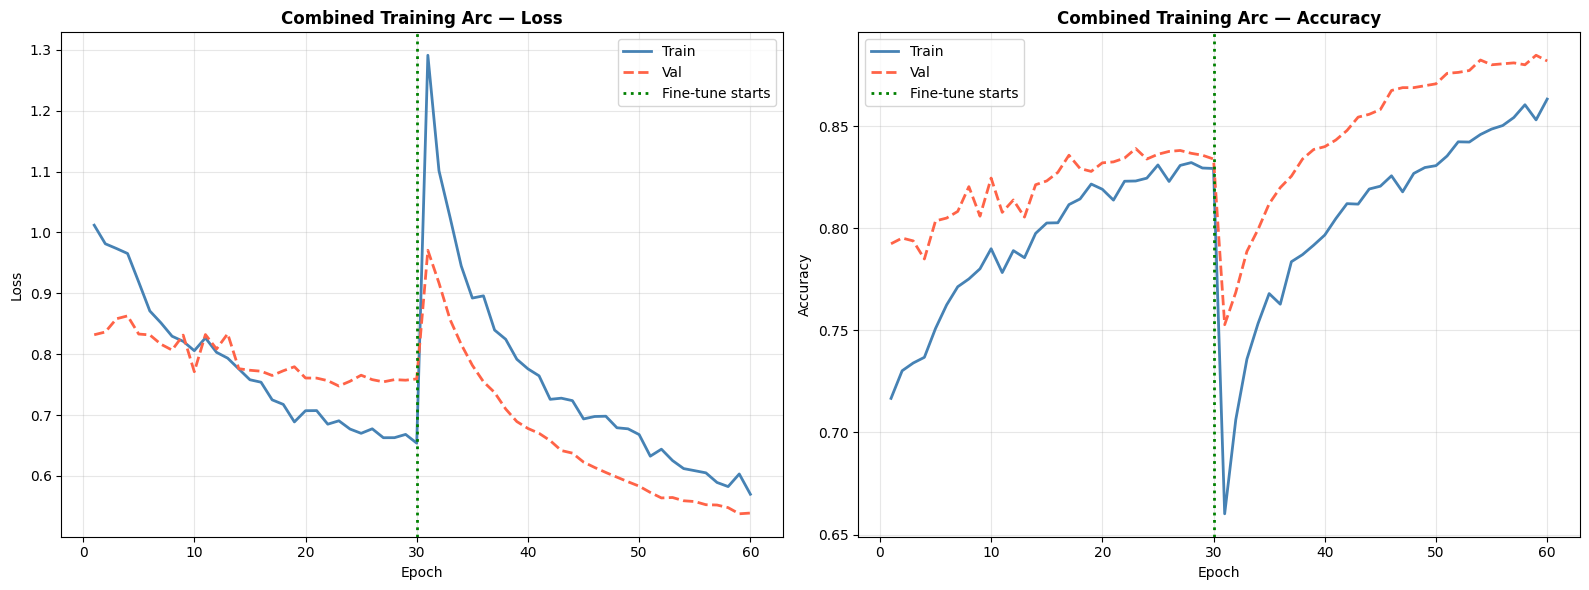

Green dotted line = start of fine-tuning phase (Phase 2)


In [85]:
# ── Phase 2 curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_ft.history['loss'],     label='Train Loss', color='darkorange', linewidth=2)
axes[0].plot(history_ft.history['val_loss'], label='Val Loss',   color='crimson',   linewidth=2, linestyle='--')
axes[0].set_title('Phase 2 (Fine-Tuning) — Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_ft.history['accuracy'],     label='Train Accuracy', color='darkorange', linewidth=2)
axes[1].plot(history_ft.history['val_accuracy'], label='Val Accuracy',   color='crimson',   linewidth=2, linestyle='--')
axes[1].set_title('Phase 2 (Fine-Tuning) — Accuracy', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("phase2_finetuning_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Combined Phase 1 + Phase 2 accuracy (full training arc) ───────────────
combined_train_acc = history_fe.history['accuracy']   + history_ft.history['accuracy']
combined_val_acc   = history_fe.history['val_accuracy'] + history_ft.history['val_accuracy']
combined_train_loss= history_fe.history['loss']       + history_ft.history['loss']
combined_val_loss  = history_fe.history['val_loss']   + history_ft.history['val_loss']
phase1_end = len(history_fe.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
epochs_range = range(1, len(combined_train_acc) + 1)

for ax, train, val, ylabel, title in [
    (axes[0], combined_train_loss, combined_val_loss,  'Loss',     'Combined Training Arc — Loss'),
    (axes[1], combined_train_acc,  combined_val_acc,   'Accuracy', 'Combined Training Arc — Accuracy'),
]:
    ax.plot(epochs_range, train, label='Train', color='steelblue',  linewidth=2)
    ax.plot(epochs_range, val,   label='Val',   color='tomato',     linewidth=2, linestyle='--')
    ax.axvline(x=phase1_end, color='green', linestyle=':', linewidth=2, label='Fine-tune starts')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("tl_combined_arc.png", dpi=150, bbox_inches='tight')
plt.show()
print("Green dotted line = start of fine-tuning phase (Phase 2)")


### 2.6.3 Model Evaluation and Prediction


  Transfer Learning Model — Evaluation
  Val Accuracy : 88.48%
  Val Loss     : 0.5379
67/67 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step

Classification Report — EfficientNetB0 (Transfer Learning):
              precision    recall  f1-score   support

           0       0.90      0.81      0.85        57
           1       0.91      0.86      0.88        57
          10       0.83      0.95      0.89        58
          11       0.95      0.95      0.95        56
          12       0.94      0.93      0.94        55
          13       0.78      0.85      0.82        55
          14       0.88      0.69      0.77        54
          15       0.84      0.74      0.79        57
          16       0.95      0.98      0.97        58
          17       0.96      0.96      0.96        57
          18       0.76      0.79      0.78        57
          19       0.94      0.77      0.85        57
           2       0.96      0.91      0.94        58
          20       0.83      0.93      0.88        57


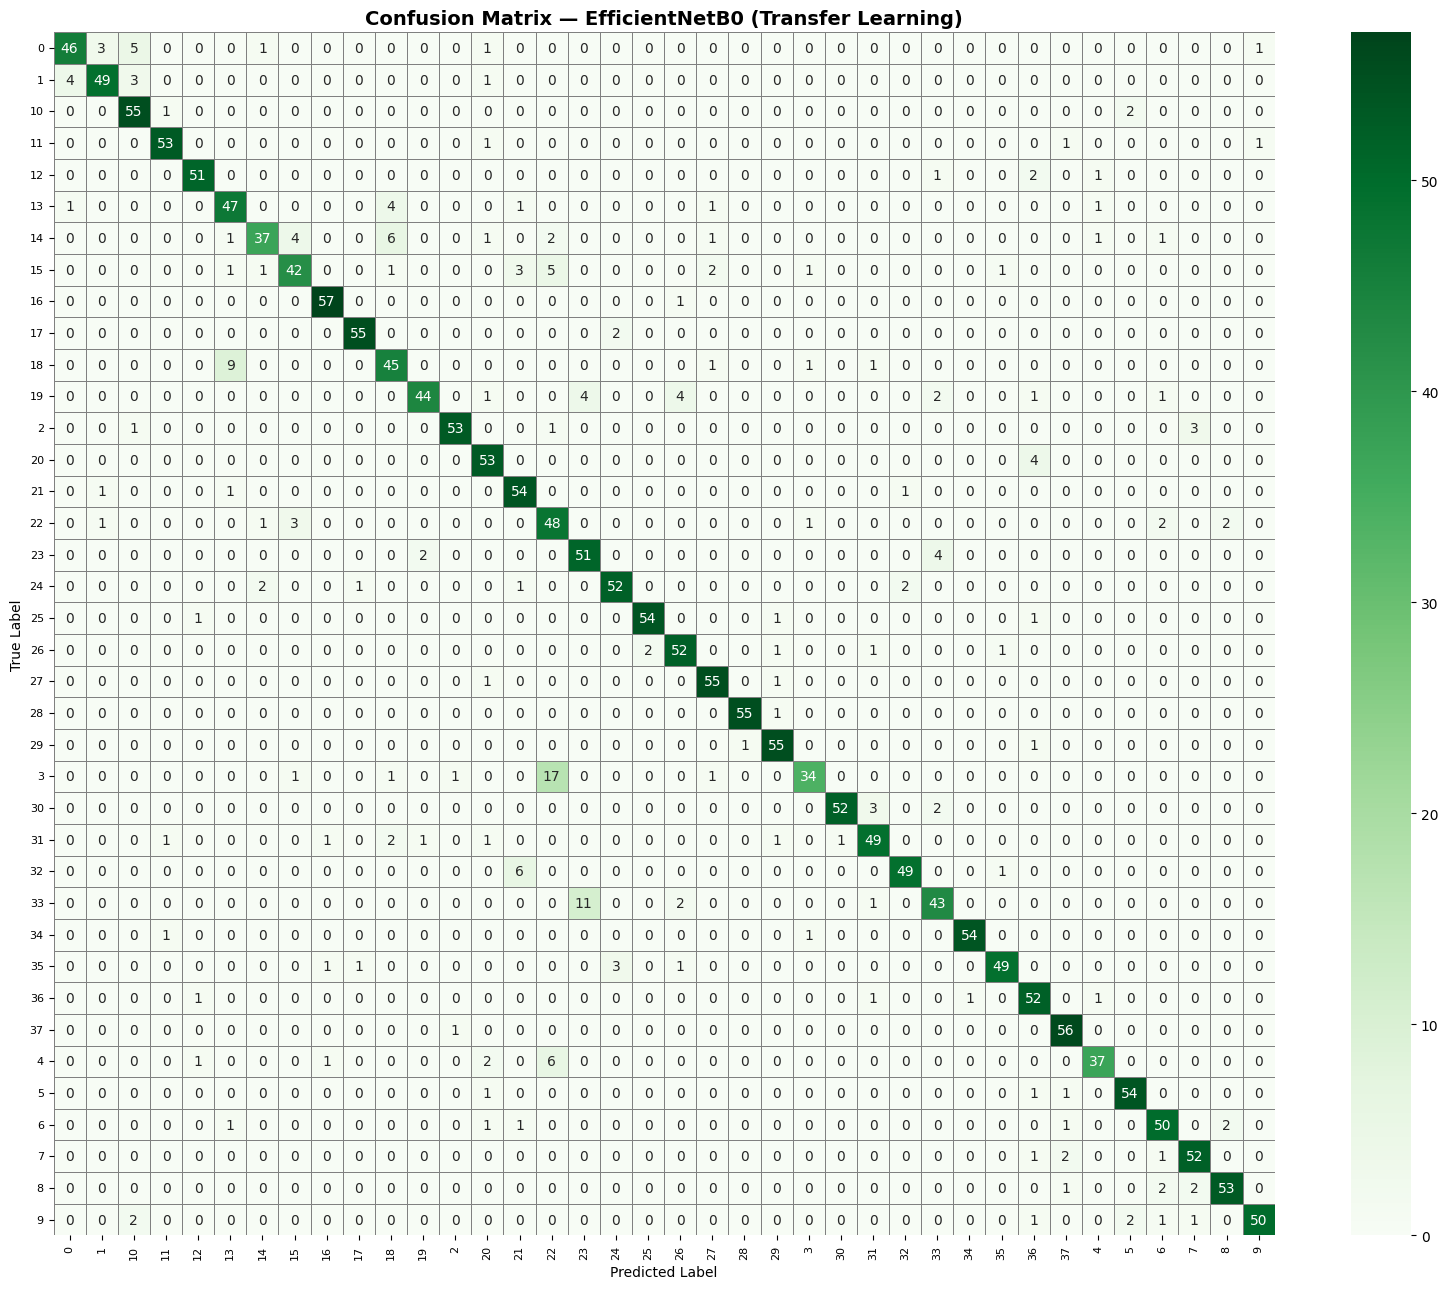

In [86]:
print("\n" + "=" * 55)
print("  Transfer Learning Model — Evaluation")
print("=" * 55)

val_gen_tl.reset()
tl_val_loss, tl_val_acc = tl_model.evaluate(val_gen_tl, verbose=0)
print(f"  Val Accuracy : {tl_val_acc*100:.2f}%")
print(f"  Val Loss     : {tl_val_loss:.4f}")

# Predictions
val_gen_tl.reset()
y_pred_probs_tl = tl_model.predict(val_gen_tl, verbose=1)
y_pred_tl       = np.argmax(y_pred_probs_tl, axis=1)
y_true_tl       = val_gen_tl.classes

print("\nClassification Report — EfficientNetB0 (Transfer Learning):")
print(classification_report(y_true_tl, y_pred_tl, target_names=CLASS_NAMES_TL, zero_division=0))

# Confusion matrix
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
plt.figure(figsize=(16, 13))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES_TL, yticklabels=CLASS_NAMES_TL,
            linewidths=0.4, linecolor='grey')
plt.title("Confusion Matrix — EfficientNetB0 (Transfer Learning)", fontsize=14, fontweight='bold')
plt.xlabel("Predicted Label"); plt.ylabel("True Label")
plt.xticks(rotation=90, fontsize=8); plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("confusion_matrix_tl.png", dpi=150, bbox_inches='tight')
plt.show()


Found 3 validated image filenames.


2026-05-09 14:51:08.748270: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:51:08.883764: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:51:09.652497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 14:51:09.788004: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step


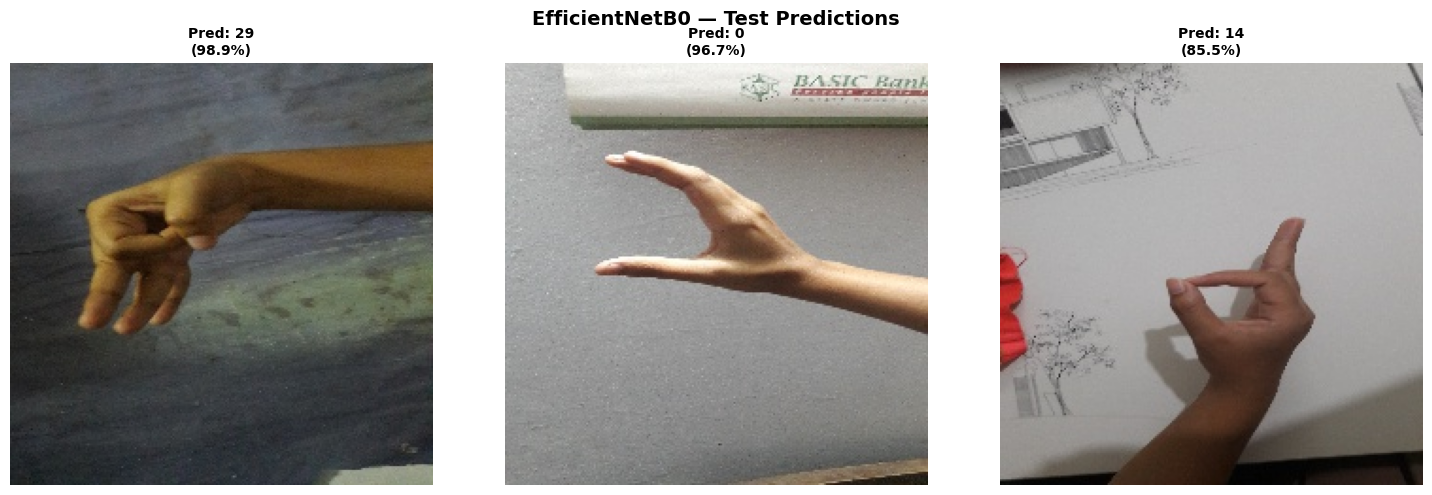

In [95]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Get test filenames
test_files = [
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

# Create dataframe
test_df = pd.DataFrame({
    'filename': test_files
})

# Generator
test_datagen_tl = ImageDataGenerator()

test_gen_tl = test_datagen_tl.flow_from_dataframe(
    dataframe=test_df,
    directory=TEST_DIR,
    x_col='filename',
    y_col=None,
    target_size=IMG_SIZE_TL,
    batch_size=1,
    class_mode=None,
    shuffle=False
)

# Predict
y_pred_probs = tl_model.predict(test_gen_tl, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# Class labels
class_labels = list(train_gen.class_indices.keys())

# Number of images
n_images = len(test_files)

# Create figure dynamically
fig, axes = plt.subplots(1, n_images, figsize=(5 * n_images, 5))

# If only 1 image
if n_images == 1:
    axes = [axes]

for i in range(n_images):

    img_path = os.path.join(TEST_DIR, test_files[i])
    img = plt.imread(img_path)

    pred_label = class_labels[y_pred[i]]
    conf = np.max(y_pred_probs[i]) * 100

    axes[i].imshow(img)
    axes[i].set_title(
        f"Pred: {pred_label}\n({conf:.1f}%)",
        fontsize=10,
        fontweight='bold'
    )
    axes[i].axis('off')

plt.suptitle(
    "EfficientNetB0 — Test Predictions",
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Final Comparison: Transfer Learning vs Part A Models

  FINAL COMPARISON: All Models
Metric                           Baseline   Deeper(Adam)   EfficientNetB0
---------------------------------------------------------------------------
Val Accuracy                       61.01%         77.19%           88.48%
Val Loss                           1.5556         1.0259           0.5379
Weighted Precision                 0.6419         0.7960           0.8900
Weighted Recall                    0.6101         0.7719           0.8848
Weighted F1-Score                  0.5970         0.7748           0.8846
Training Time (min)                  8.8m          16.7m            92.6m


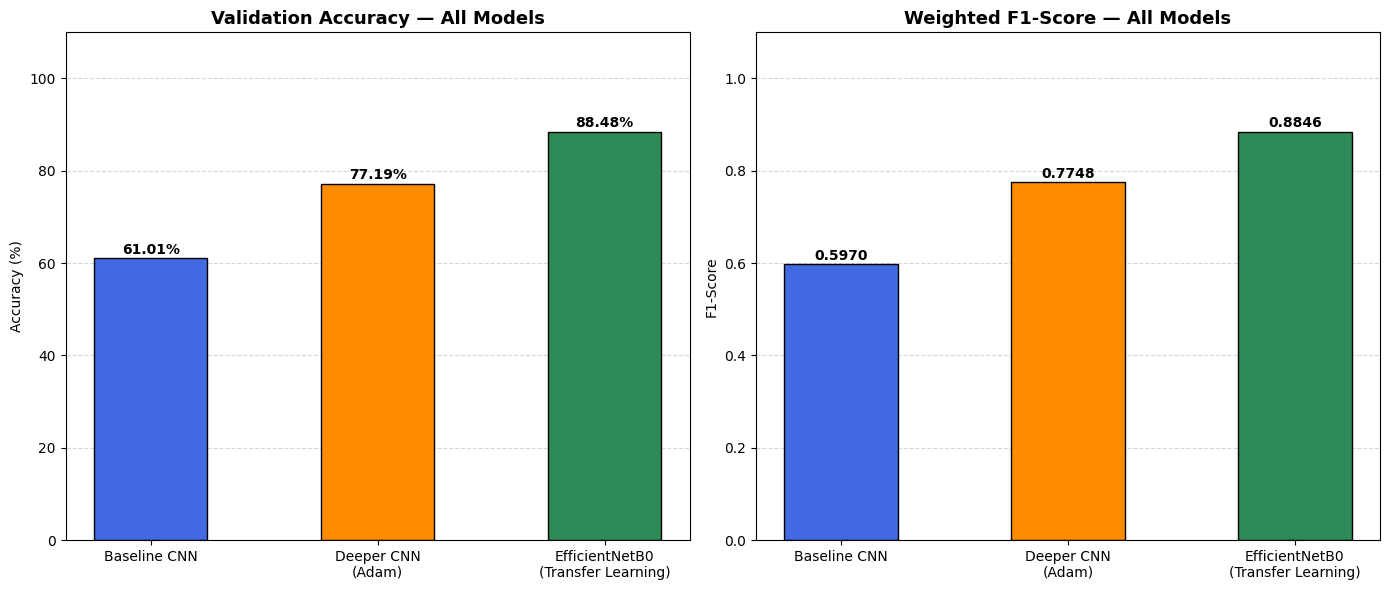

In [96]:
# ── Compute TL metrics ────────────────────────────────────────────────────
prec_tl = precision_score(y_true_tl, y_pred_tl, average='weighted', zero_division=0)
rec_tl  = recall_score(y_true_tl,   y_pred_tl, average='weighted', zero_division=0)
f1_tl   = f1_score(y_true_tl,       y_pred_tl, average='weighted', zero_division=0)

# ── Recompute Part A metrics if not already in session ────────────────────
# Baseline
val_gen.reset()
y_pred_base_full = np.argmax(baseline_model.predict(val_gen, verbose=0), axis=1)
prec_base = precision_score(y_true, y_pred_base_full, average='weighted', zero_division=0)
rec_base  = recall_score(y_true,   y_pred_base_full, average='weighted', zero_division=0)

# Deeper (Adam)
val_gen.reset()
y_pred_deep_full = np.argmax(deeper_model.predict(val_gen, verbose=0), axis=1)
prec_deep = precision_score(y_true, y_pred_deep_full, average='weighted', zero_division=0)
rec_deep  = recall_score(y_true,   y_pred_deep_full, average='weighted', zero_division=0)

print("=" * 75)
print("  FINAL COMPARISON: All Models")
print("=" * 75)
print(f"{'Metric':<28} {'Baseline':>12} {'Deeper(Adam)':>14} {'EfficientNetB0':>16}")
print("-" * 75)
print(f"{'Val Accuracy':<28} {val_acc_base*100:>11.2f}% {val_acc_deep*100:>13.2f}% {tl_val_acc*100:>15.2f}%")
print(f"{'Val Loss':<28} {val_loss_base:>12.4f} {val_loss_deep:>14.4f} {tl_val_loss:>16.4f}")
print(f"{'Weighted Precision':<28} {prec_base:>12.4f} {prec_deep:>14.4f} {prec_tl:>16.4f}")
print(f"{'Weighted Recall':<28} {rec_base:>12.4f} {rec_deep:>14.4f} {rec_tl:>16.4f}")
print(f"{'Weighted F1-Score':<28} {f1_base:>12.4f} {f1_deep:>14.4f} {f1_tl:>16.4f}")
print(f"{'Training Time (min)':<28} {baseline_train_time/60:>11.1f}m {deeper_train_time/60:>13.1f}m {tl_total_time/60:>15.1f}m")
print("=" * 75)

# ── Bar chart comparison ───────────────────────────────────────────────────
model_names = ['Baseline CNN', 'Deeper CNN\n(Adam)', 'EfficientNetB0\n(Transfer Learning)']
accuracies  = [val_acc_base*100, val_acc_deep*100, tl_val_acc*100]
f1_scores_all = [f1_base, f1_deep, f1_tl]
colors      = ['royalblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

bars0 = axes[0].bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Validation Accuracy — All Models', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)'); axes[0].set_ylim(0, 110)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5); axes[0].set_axisbelow(True)
for bar, val in zip(bars0, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

bars1 = axes[1].bar(model_names, f1_scores_all, color=colors, edgecolor='black', width=0.5)
axes[1].set_title('Weighted F1-Score — All Models', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score'); axes[1].set_ylim(0, 1.1)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.5); axes[1].set_axisbelow(True)
for bar, val in zip(bars1, f1_scores_all):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("final_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


### Discussion: Does Transfer Learning Outperform Training from Scratch?

Yes, transfer learning clearly outperformed training from scratch. The EfficientNetB0 model achieved a validation accuracy of 88.48%, validation loss of 0.5379, weighted precision of 0.8900, weighted recall of 0.8848, and weighted F1-score of 0.8846. Compared to the deeper CNN which achieved 77.19% accuracy and F1-score of 0.7748, and the baseline CNN which achieved only 61.01% accuracy and F1-score of 0.5970, the improvement brought by transfer learning is substantial and consistent across every metric.

